### Step 1: Dataset Understanding

First, we'll load the dataset and perform an initial inspection to understand its structure, data types, and check for missing values or duplicates.

In [4]:
import pandas as pd

# Load the dataset, explicitly specifying dtype for 'Cluster' to avoid DtypeWarning
df = pd.read_csv('/content/Final Dataset - Merged.csv', dtype={'Cluster': str}, low_memory=False)

print('Dataset loaded successfully!')

Dataset loaded successfully!


#### Display the first 10 rows

In [2]:
display(df.head(10))

,location,survey_type,month,year,recall_period,HH,Cluster,Team,Total,Births,Deaths,Joined,Left,Total_U5,Births_U5,Deaths_U5,Joined_U5,Left_U5,Person_Time,Person_Time_U5
0,Gaalkacyo,admin2_individual,6.0,2018.0,96,1,16,1.0,6,0,0,0,0,2,0,0,0,0,576.0,192.0
1,Gaalkacyo,admin2_individual,6.0,2018.0,96,2,16,1.0,5,0,0,0,0,2,0,0,0,0,480.0,192.0
2,Gaalkacyo,admin2_individual,6.0,2018.0,96,3,16,1.0,2,0,0,0,0,0,0,0,0,0,192.0,0.0
3,Gaalkacyo,admin2_individual,6.0,2018.0,96,4,16,1.0,5,0,0,0,0,2,0,0,0,0,480.0,192.0
4,Gaalkacyo,admin2_individual,6.0,2018.0,96,5,16,1.0,8,0,0,0,0,1,0,0,0,0,768.0,96.0
5,Gaalkacyo,admin2_individual,6.0,2018.0,96,6,16,1.0,4,0,0,0,0,2,0,0,0,0,384.0,192.0
6,Gaalkacyo,admin2_individual,6.0,2018.0,96,7,16,1.0,6,0,0,0,0,2,0,0,0,0,576.0,192.0
7,Gaalkacyo,admin2_individual,6.0,2018.0,96,8,16,1.0,4,0,0,0,0,1,0,0,0,0,384.0,96.0
8,Gaalkacyo,admin2_individual,6.0,2018.0,96,9,16,1.0,5,0,0,0,0,2,0,0,0,0,480.0,192.0
9,Gaalkacyo,admin2_individual,6.0,2018.0,96,10,16,1.0,12,0,0,0,0,3,0,0,0,0,1152.0,288.0


#### Display dataset information and data types

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42538 entries, 0 to 42537
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        42538 non-null  object 
 1   survey_type     42538 non-null  object 
 2   month           40567 non-null  float64
 3   year            41159 non-null  float64
 4   recall_period   42538 non-null  int64  
 5   HH              41140 non-null  object 
 6   Cluster         41159 non-null  object 
 7   Team            41141 non-null  float64
 8   Total           42538 non-null  int64  
 9   Births          42538 non-null  int64  
 10  Deaths          42538 non-null  int64  
 11  Joined          42538 non-null  int64  
 12  Left            42538 non-null  int64  
 13  Total_U5        42538 non-null  int64  
 14  Births_U5       42538 non-null  int64  
 15  Deaths_U5       42538 non-null  int64  
 16  Joined_U5       42538 non-null  int64  
 17  Left_U5         42538 non-null 

#### Count missing values

In [5]:
missing_values = df.isnull().sum()
print("Number of missing values per column:")
display(missing_values[missing_values > 0].sort_values(ascending=False))

Number of missing values per column:


,0
month,1971
HH,1398
Team,1397
year,1379
Cluster,1379


#### Count duplicate rows

In [6]:
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

Number of duplicate rows: 1473


#### Remove duplicate rows

In [7]:
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {df.shape[0]}")

Number of rows after removing duplicates: 41065


#### Handle missing values using appropriate techniques

Before handling missing values, let's re-check the number of missing values after removing duplicates.

In [8]:
missing_values_after_dedup = df.isnull().sum()
print("Number of missing values per column after duplicate removal:")
display(missing_values_after_dedup[missing_values_after_dedup > 0].sort_values(ascending=False))

Number of missing values per column after duplicate removal:


,0
month,591
HH,20
Team,19
year,1
Cluster,1


### Handling Missing Values

- **`month`**: This column represents the month of the survey. As it's a discrete numerical value, imputing with the mode (the most frequent month) is a sensible approach. This preserves the most common monthly pattern in the dataset.
- **`HH` (Household Identifier)**: This is likely a categorical identifier. Imputing with the mode is appropriate as it assigns the most common household identifier to the missing entries.
- **`Team`**: Similar to `HH`, this likely represents a team identifier. Mode imputation will fill missing values with the most frequently occurring team ID.
- **`year`**: This column represents the year of the survey. With only 1 missing value, imputing with the mode (the most frequent year) is a robust and simple solution.
- **`Cluster`**: This is also an identifier, likely categorical. Mode imputation is used to fill the single missing value with the most common cluster identifier.

In [9]:
# Impute missing values with the mode for 'month', 'HH', 'Team', 'year', and 'Cluster'
df['month'] = df['month'].fillna(df['month'].mode()[0])
df['HH'] = df['HH'].fillna(df['HH'].mode()[0])
df['Team'] = df['Team'].fillna(df['Team'].mode()[0])
df['year'] = df['year'].fillna(df['year'].mode()[0])
df['Cluster'] = df['Cluster'].fillna(df['Cluster'].mode()[0])

print("Missing values handled successfully.")

# Verify that there are no more missing values in these columns
print("\nMissing values after imputation:")
display(df[['month', 'HH', 'Team', 'year', 'Cluster']].isnull().sum())

Missing values handled successfully.

Missing values after imputation:


,0
month,0
HH,0
Team,0
year,0
Cluster,0


### Explanation of Preprocessing Steps (So Far)

We have completed the initial dataset understanding and cleaning steps. Here's a breakdown of each action and its rationale:

1.  **Load the dataset:** We loaded the `Final Dataset - Merged.csv` file into a pandas DataFrame. During loading, we explicitly specified `dtype={'Cluster': str}` to handle a `DtypeWarning` which indicated mixed data types in the 'Cluster' column. This ensures consistency and prevents potential errors in future operations.

2.  **Display first 10 rows (`df.head(10)`):** This step was performed to get a quick glimpse of the data structure, column names, and the types of values present in the initial rows. It helps in early identification of potential issues like incorrect parsing or unexpected data formats.

3.  **Display dataset information and data types (`df.info()`):** This provided a comprehensive summary of the DataFrame, including the number of entries, column names, non-null counts for each column, and their respective data types. This was crucial for identifying columns with missing values and understanding the overall memory usage.

4.  **Count missing values (`df.isnull().sum()`):** We calculated the number of missing values for each column. This step is vital for understanding data completeness and deciding on appropriate imputation strategies. Initially, columns like `month`, `year`, `HH`, `Cluster`, and `Team` showed missing values.

5.  **Count duplicate rows (`df.duplicated().sum()`):** Identifying and quantifying duplicate rows is important to ensure that each record in the dataset is unique. Duplicate entries can lead to biased analyses and inflated model performance metrics.

6.  **Remove duplicate rows (`df.drop_duplicates(inplace=True)`):** We removed all identified duplicate rows from the dataset. This ensures data integrity and that each observation contributes uniquely to the analysis.

7.  **Re-check missing values:** After removing duplicates, we re-evaluated the missing values count. This is a good practice to see if duplicate removal influenced the number of missing entries, ensuring we work with the most current state of missingness.

8.  **Handle missing values (Mode Imputation):** For the remaining missing values in `month`, `HH`, `Team`, `year`, and `Cluster`, we used **mode imputation**. This technique replaces missing values with the most frequently occurring value in that column.
    *   **Rationale:** These columns (`month`, `year`, `HH`, `Team`, `Cluster`) are either categorical (identifiers like HH, Cluster, Team) or discrete numerical values (month, year). Mode imputation is suitable for such data types as it preserves the most common value, minimizing distortion to the distribution, especially when the number of missing values is relatively small for `year`, `HH`, `Team`, and `Cluster`.

With these steps, our dataset is now clean and ready for Exploratory Data Analysis (EDA).

### Step 2: Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is a crucial step to understand the data's characteristics, identify patterns, detect anomalies, and form hypotheses. We will cover the following aspects:

*   Dataset shape
*   Statistical summary
*   Distribution of every feature
*   Correlation matrix
*   Heatmaps
*   Histograms
*   Boxplots
*   Pairplots (if suitable)
*   Class distribution
*   Outlier detection

#### Dataset Shape

Let's check the number of rows and columns in our dataset after preprocessing.

In [10]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 41065 rows, 20 columns


#### Statistical Summary

Let's view the statistical summary of the numerical columns to understand their central tendency, dispersion, and shape of the distribution.

In [11]:
display(df.describe())

,month,year,recall_period,Team,Total,Births,Deaths,Joined,Left,Total_U5,Births_U5,Deaths_U5,Joined_U5,Left_U5,Person_Time,Person_Time_U5
count,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000,41065.000000
mean,6.265214,2018.854840,96.242810,3.992580,4.351808,0.070181,0.016973,0.059808,0.088543,1.129258,0.060465,0.008182,0.008109,0.006867,422.733179,108.060989
std,2.619995,3.076148,6.518451,2.281299,2.471622,0.279317,0.142783,0.319854,0.347406,1.033200,0.243304,0.092486,0.100928,0.099196,244.879531,99.360675
min,1.000000,2013.000000,90.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,2018.000000,93.000000,2.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,270.000000,0.000000
50%,6.000000,2020.000000,93.000000,4.000000,4.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,408.000000,96.000000
75%,8.000000,2022.000000,98.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,576.000000,192.000000
max,12.000000,2023.000000,125.000000,85.000000,31.000000,6.000000,5.000000,10.000000,7.000000,5.000000,6.000000,2.000000,3.000000,4.000000,2790.000000,562.500000


#### Distribution of Every Feature

To understand the distribution of our features, we will categorize them into numerical and categorical types and then visualize them using appropriate plots. We'll use histograms for numerical features and count plots for categorical features.

Numerical columns: ['month', 'year', 'recall_period', 'Team', 'Total', 'Births', 'Deaths', 'Joined', 'Left', 'Total_U5', 'Births_U5', 'Deaths_U5', 'Joined_U5', 'Left_U5', 'Person_Time', 'Person_Time_U5']
Categorical columns: ['location', 'survey_type', 'HH', 'Cluster']

Plotting Histograms for Numerical Features...


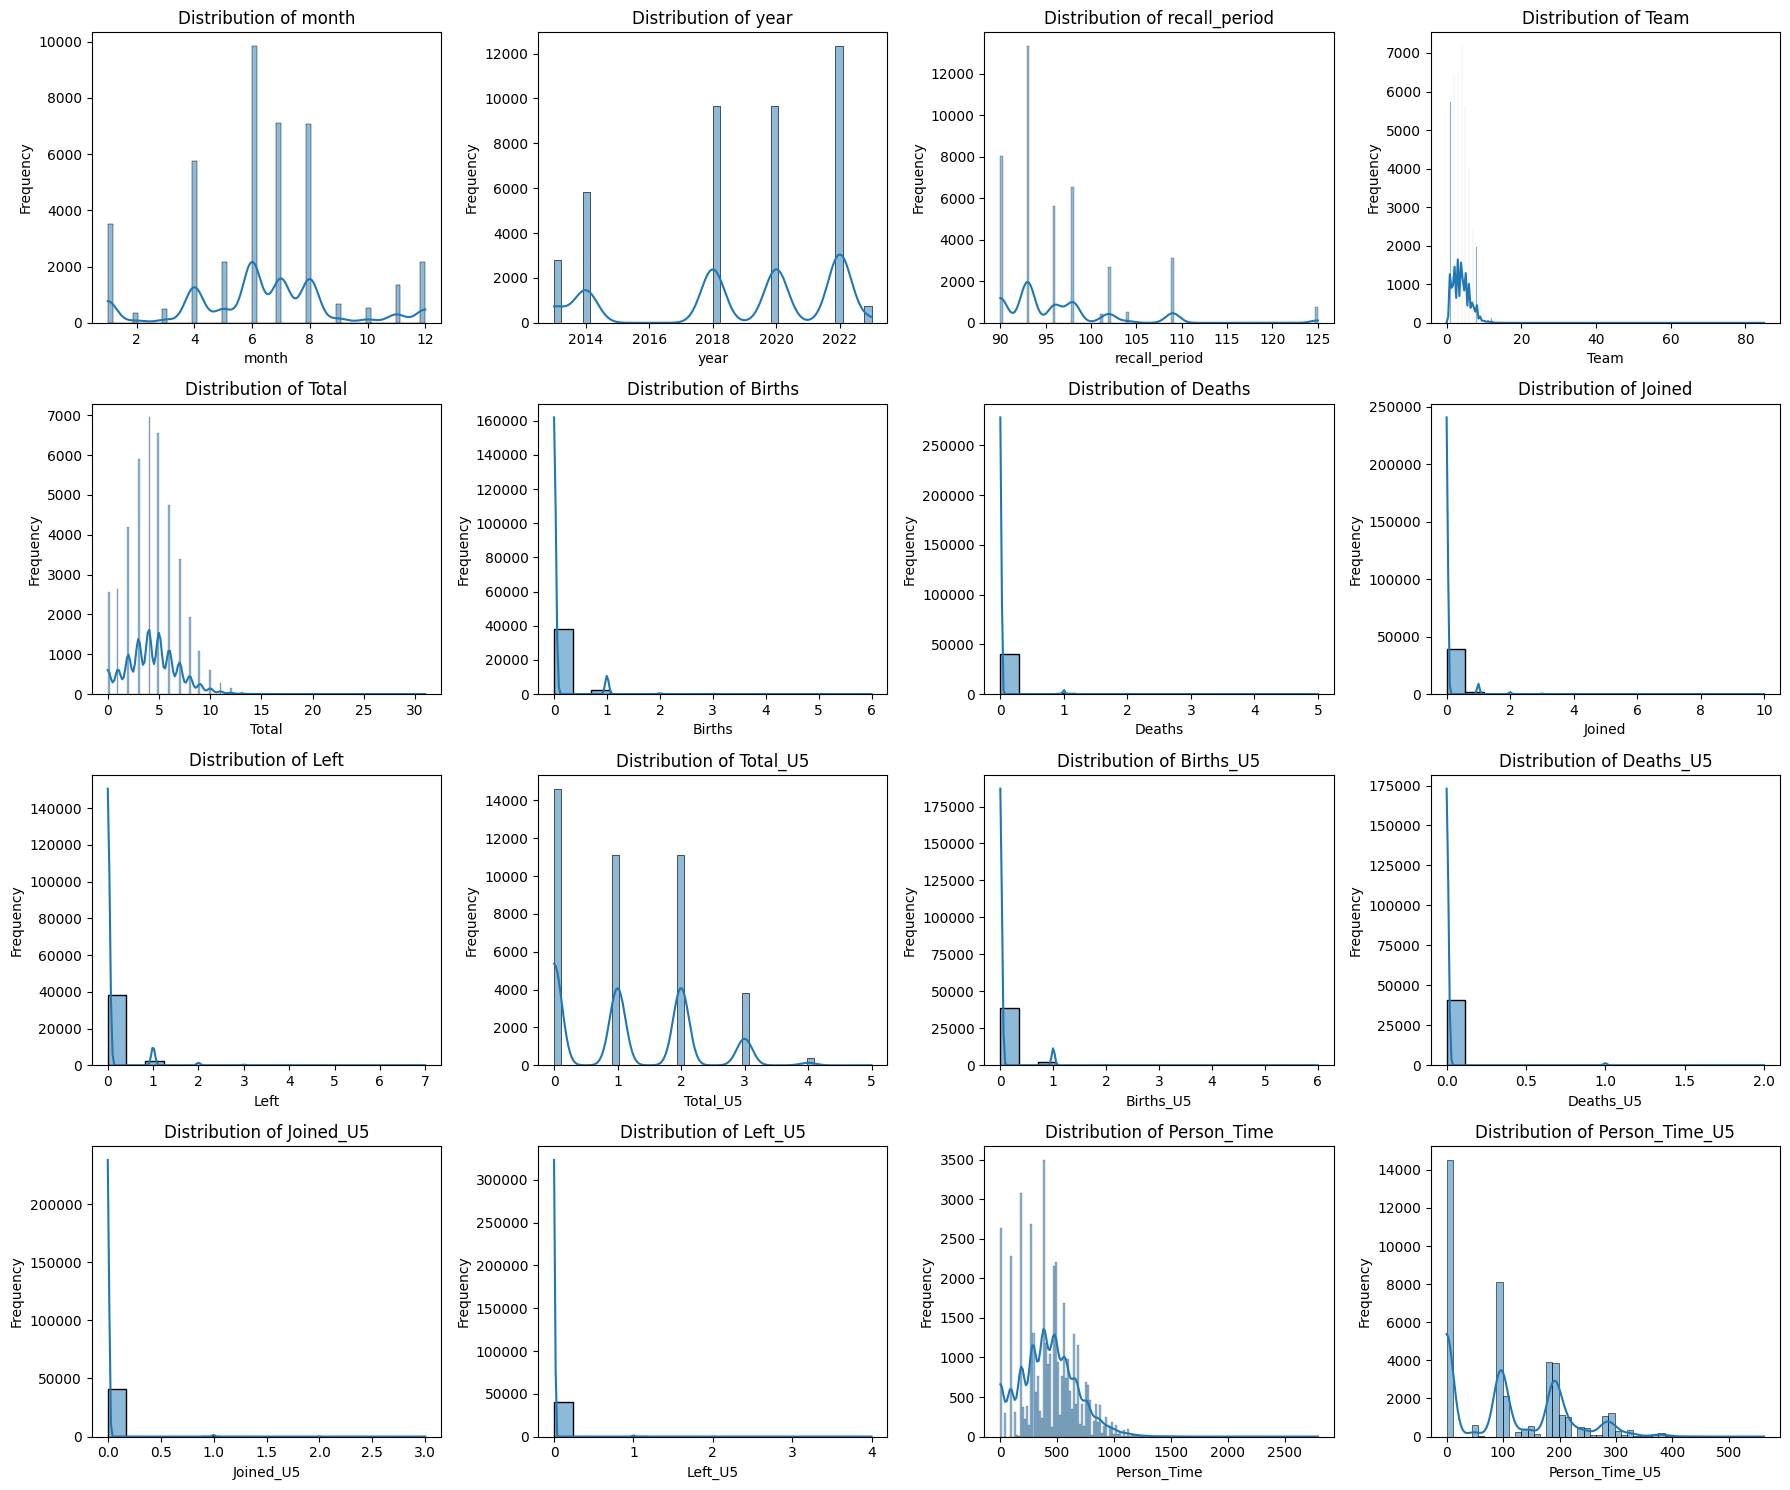


Plotting Count Plots for Categorical Features...


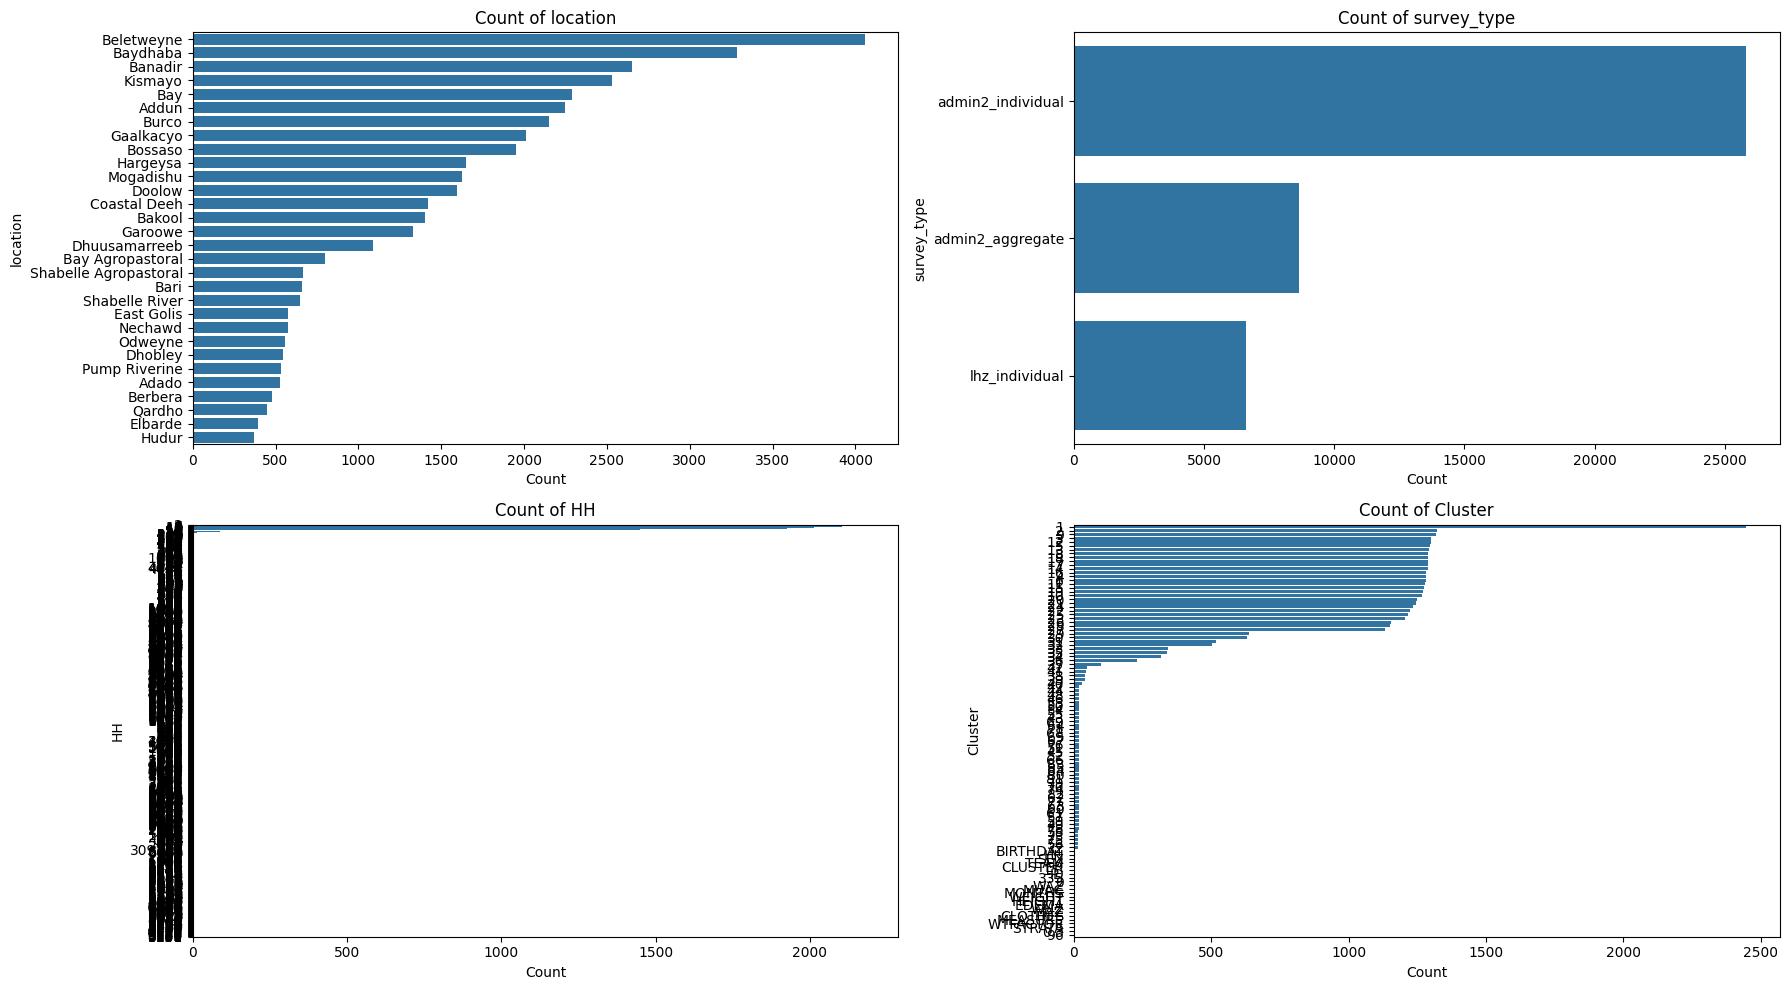

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Numerical columns:", numerical_cols.tolist())
print("Categorical columns:", categorical_cols.tolist())

# Plot histograms for numerical features
print("\nPlotting Histograms for Numerical Features...")
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Plot count plots for categorical features
print("\nPlotting Count Plots for Categorical Features...")
plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 2, i + 1) # Adjust subplot grid as needed
    sns.countplot(y=df[col], order = df[col].value_counts().index)
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Correlation Matrix and Heatmap

To understand the linear relationships between numerical features, we will compute the correlation matrix and visualize it using a heatmap. This helps identify highly correlated features, which might indicate multicollinearity.

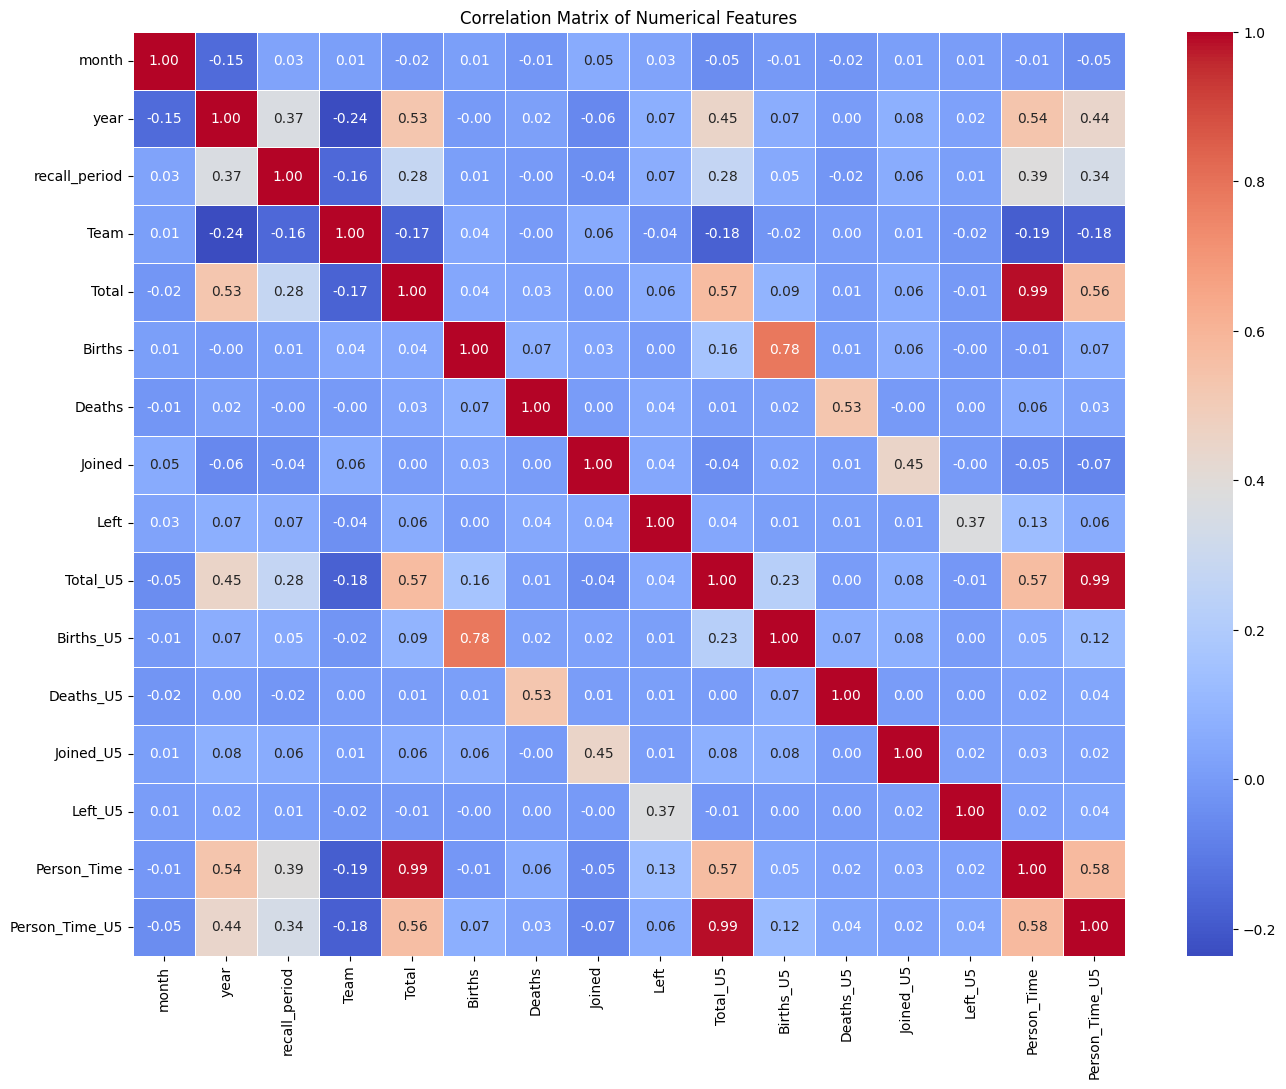

In [13]:
# Calculate the correlation matrix for numerical columns
correlation_matrix = df[numerical_cols].corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Boxplots

Boxplots are useful for visualizing the distribution of numerical data and identifying potential outliers. We will generate boxplots for all numerical features.


Plotting Boxplots for Numerical Features...


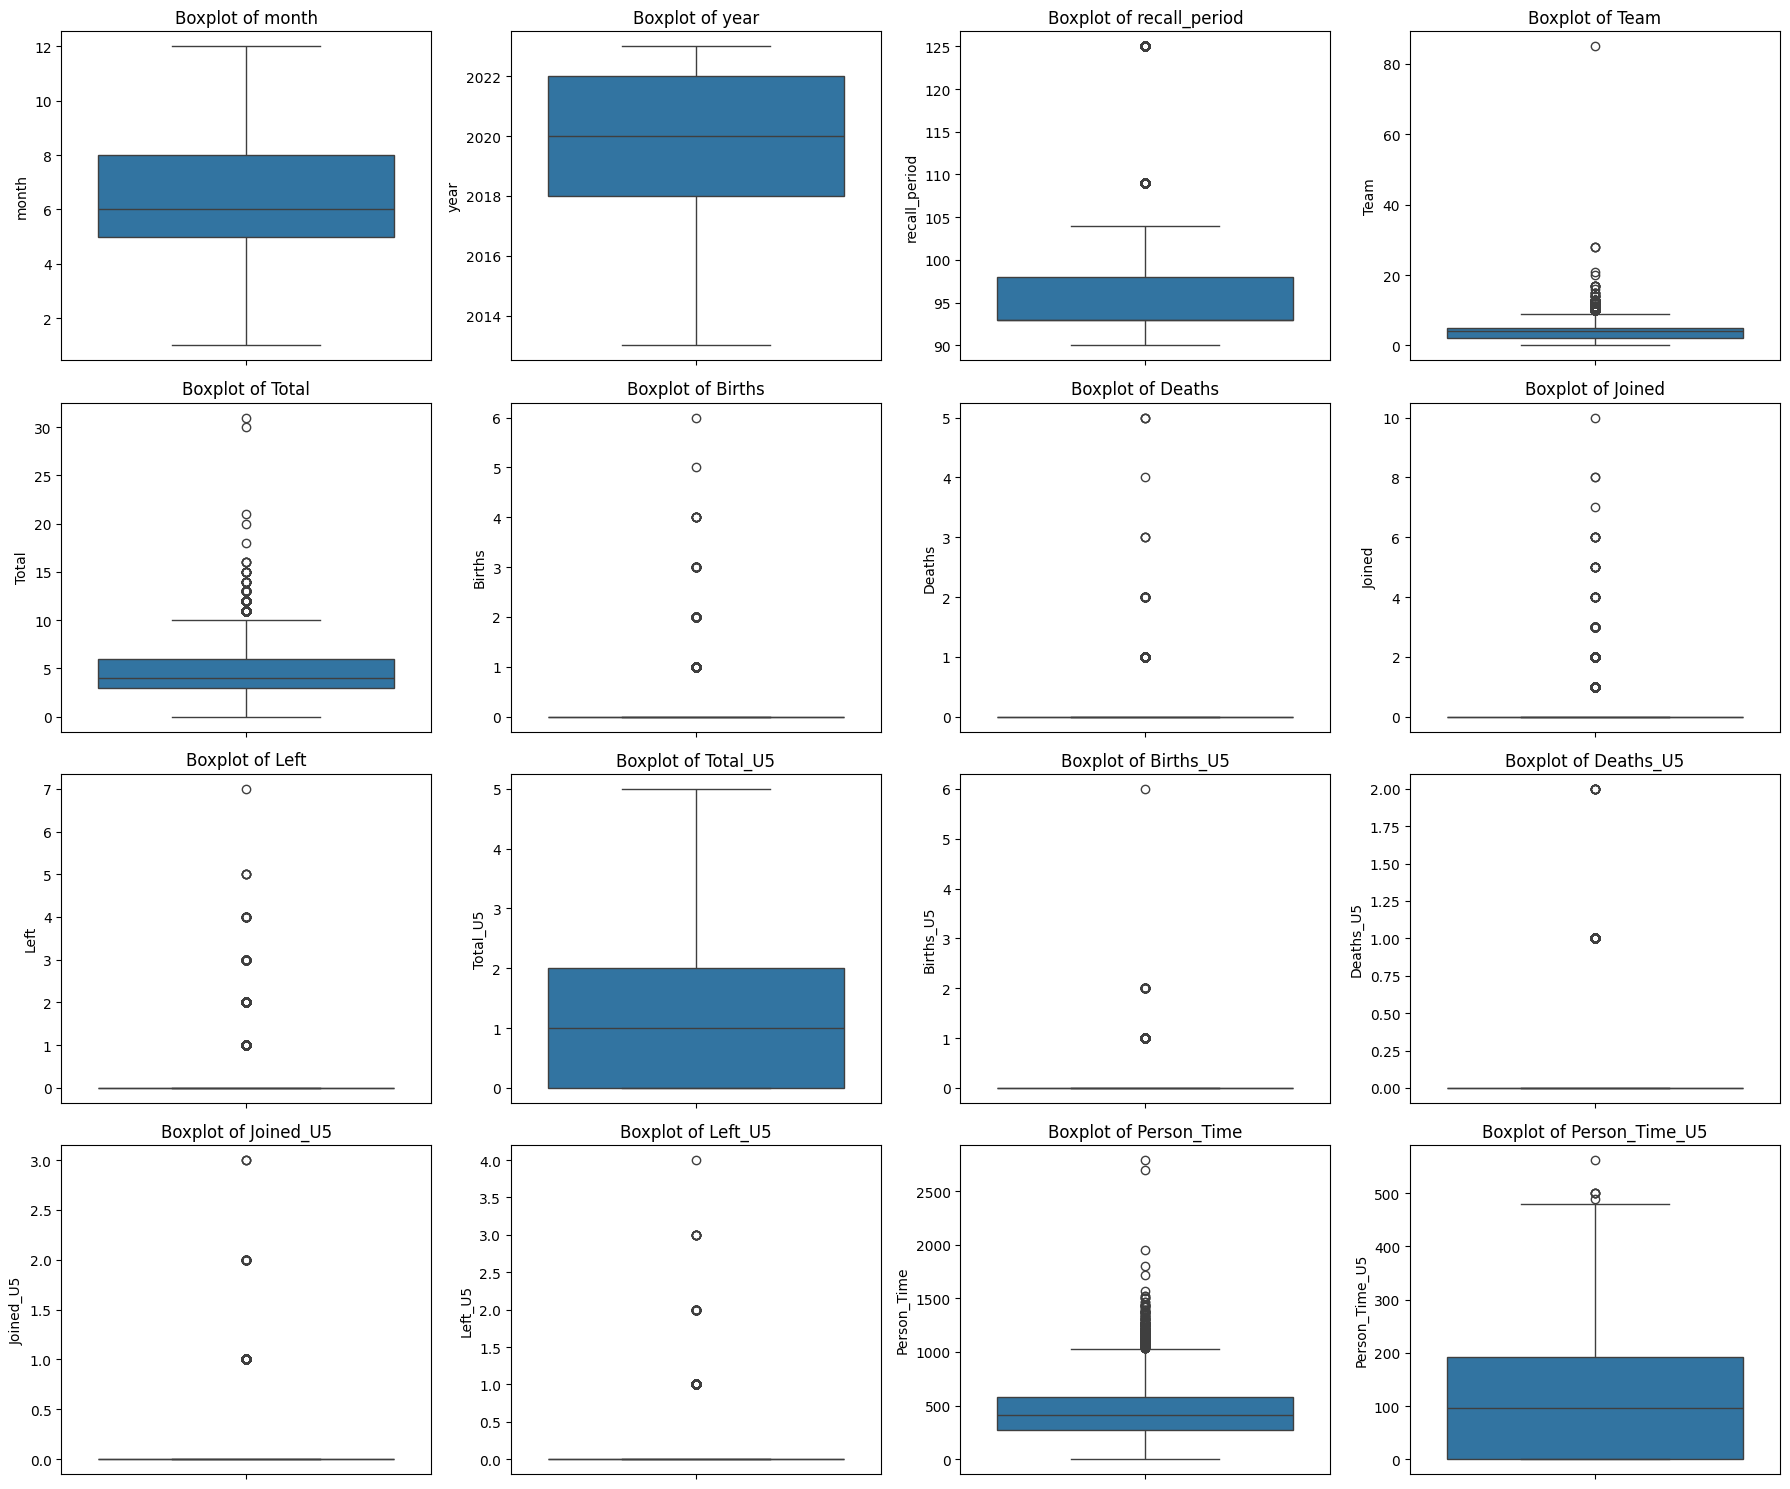

In [14]:
print("\nPlotting Boxplots for Numerical Features...")
plt.figure(figsize=(18, 15))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

#### Pairplots (for a subset of numerical features)

Pairplots are useful for visualizing the relationships between all pairs of numerical features. Due to the large number of numerical features, generating a pairplot for all of them might be computationally intensive and the resulting plot could be difficult to interpret. Therefore, we will select a subset of key numerical features that are likely to be most relevant for our analysis to generate the pairplot.


Generating Pairplots for a Subset of Numerical Features...


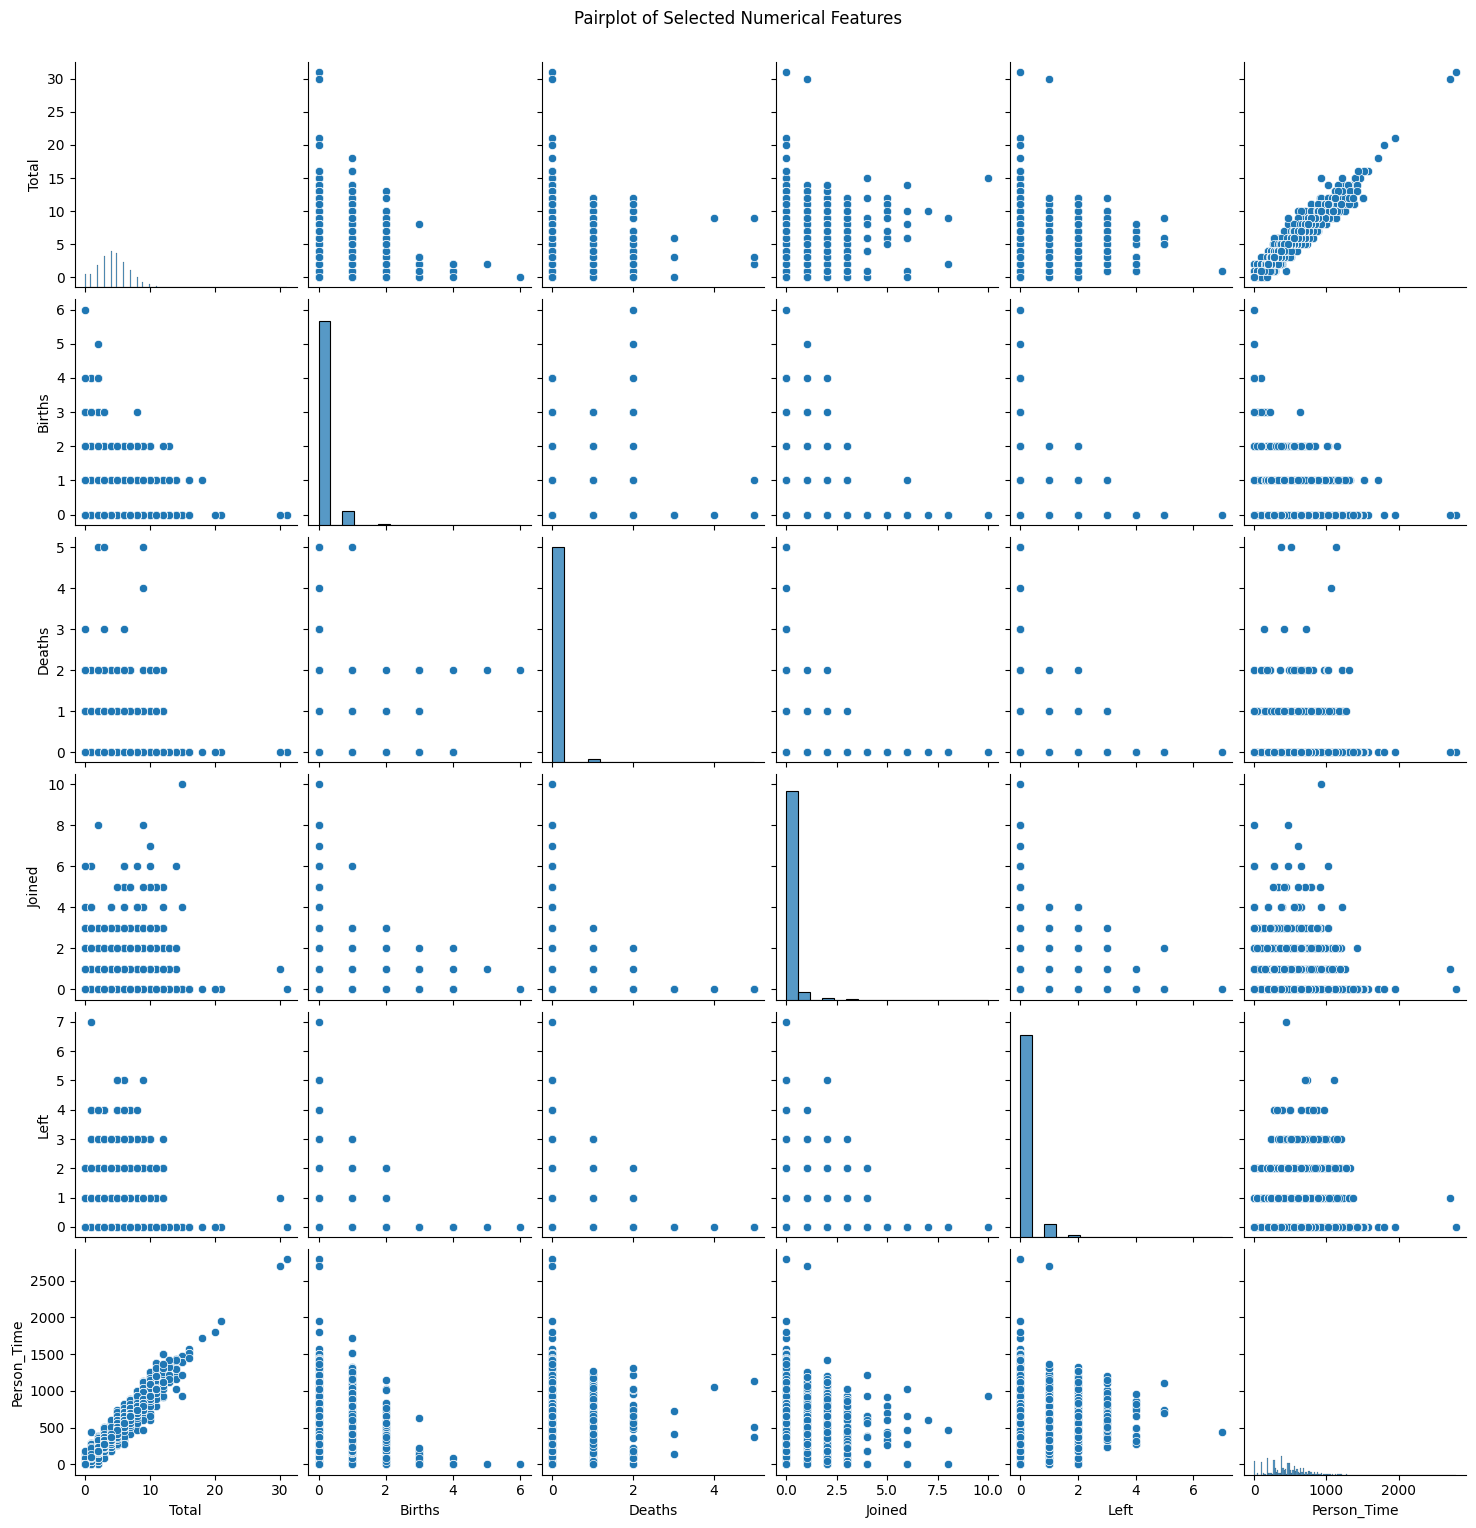

In [15]:
print("\nGenerating Pairplots for a Subset of Numerical Features...")

# Select a subset of numerical columns for pairplot
# Avoid highly correlated or less informative columns for clearer visualization
selected_numerical_cols = ['Total', 'Births', 'Deaths', 'Joined', 'Left', 'Person_Time']

# Ensure all selected columns are in the dataframe
selected_numerical_cols = [col for col in selected_numerical_cols if col in df.columns]

if not selected_numerical_cols:
    print("No suitable numerical columns found for pairplot.")
else:
    sns.pairplot(df[selected_numerical_cols])
    plt.suptitle('Pairplot of Selected Numerical Features', y=1.02) # Adjust title position
    plt.show()

#### Class Distribution

Understanding the distribution of the target variable (if available and clearly defined at this stage) is crucial for classification tasks. It helps identify class imbalance issues. Since the target variable is not yet explicitly defined, we will assume for now that we might be predicting an outcome related to household dynamics or events. For a classification project, one common approach is to predict whether a household experienced any 'significant' event (e.g., a birth, death, or joining/leaving event).

However, without a specific target variable provided, let's look at the distribution of some potentially relevant categorical or near-categorical features that could serve as target variables in the future, or are important to understand in general. For now, we will focus on understanding the distribution of categorical features, which might later inform our target variable definition.


Analyzing Class Distribution for Categorical Features...


/tmp/ipykernel_3579/4251909726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


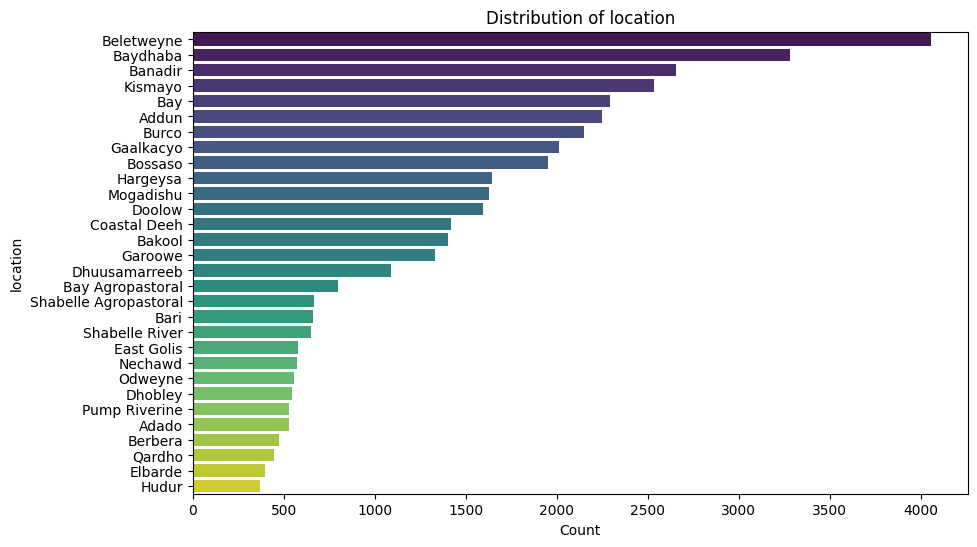


Value Counts for location:
location
Beletweyne               4056
Baydhaba                 3284
Banadir                  2654
Kismayo                  2533
Bay                      2292
Addun                    2250
Burco                    2148
Gaalkacyo                2013
Bossaso                  1950
Hargeysa                 1647
Mogadishu                1627
Doolow                   1595
Coastal Deeh             1419
Bakool                   1405
Garoowe                  1330
Dhuusamarreeb            1091
Bay Agropastoral          798
Shabelle Agropastoral     667
Bari                      659
Shabelle River            648
East Golis                577
Nechawd                   573
Odweyne                   555
Dhobley                   546
Pump Riverine             532
Adado                     529
Berbera                   476
Qardho                    447
Elbarde                   396
Hudur                     368
Name: count, dtype: int64


/tmp/ipykernel_3579/4251909726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


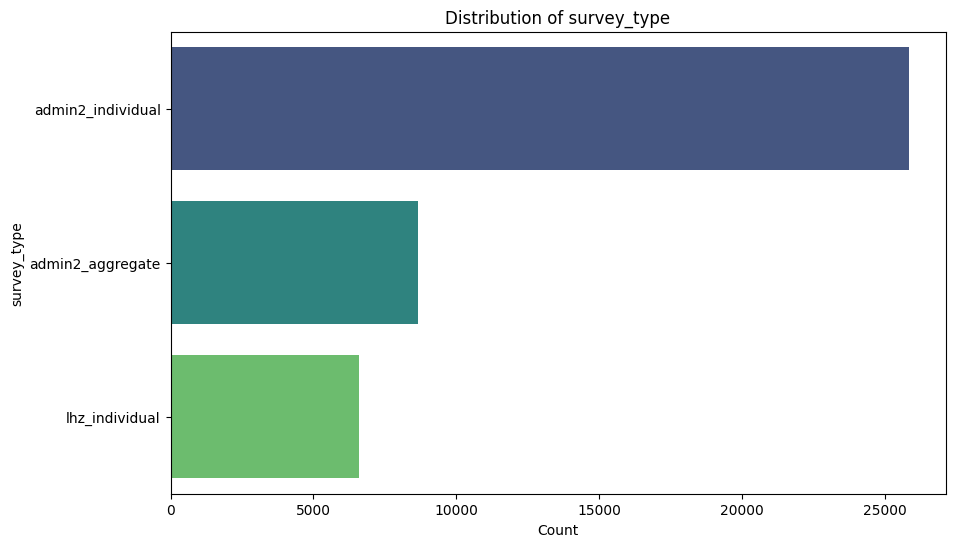


Value Counts for survey_type:
survey_type
admin2_individual    25819
admin2_aggregate      8641
lhz_individual        6605
Name: count, dtype: int64


/tmp/ipykernel_3579/4251909726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


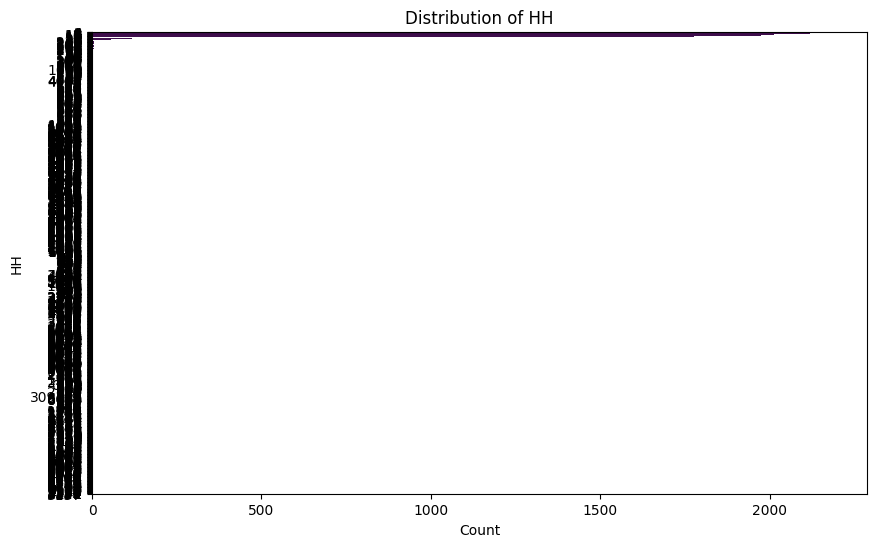


Value Counts for HH:
HH
2       2178
4       2149
1       2148
6       2145
8       2124
        ... 
3152       1
3151       1
3150       1
4141       1
3157       1
Name: count, Length: 1522, dtype: int64


/tmp/ipykernel_3579/4251909726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')


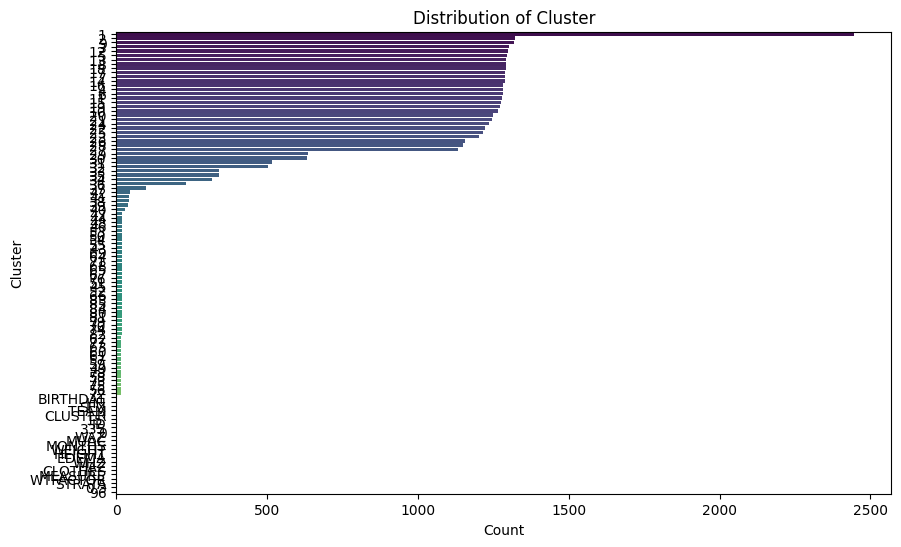


Value Counts for Cluster:
Cluster
1           2447
2           1321
9           1320
3           1301
12          1300
            ... 
MEASURE        1
WTFACTOR       1
STRATA         1
0.3            1
96             1
Name: count, Length: 108, dtype: int64


In [16]:
print("\nAnalyzing Class Distribution for Categorical Features...")

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df[col], order = df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

    # Display value counts as well
    print(f"\nValue Counts for {col}:\n{df[col].value_counts()}")

In [18]:
print("\nQuantifying Outliers using IQR Method...")

outlier_counts = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# Display outlier counts
outlier_df = pd.DataFrame(outlier_counts.items(), columns=['Feature', 'Outlier Count'])
outlier_df = outlier_df.sort_values(by='Outlier Count', ascending=False)

print("\nNumber of Outliers per Numerical Feature (IQR Method):\n")
display(outlier_df[outlier_df['Outlier Count'] > 0])

print("\nExplanation of Outlier Detection Method:")
print("The Interquartile Range (IQR) method is used to identify outliers. For each numerical feature:")
print("1. The first quartile (Q1) and third quartile (Q3) are calculated.")
print("2. The IQR is calculated as Q3 - Q1.")
print("3. Any data point below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is considered an outlier.")
print("The table above shows the count of such outliers for each numerical feature.")


Quantifying Outliers using IQR Method...

Number of Outliers per Numerical Feature (IQR Method):



,Feature,Outlier Count
2,recall_period,3888
8,Left,3020
5,Births,2689
10,Births_U5,2444
7,Joined,1863
6,Deaths,645
3,Team,593
4,Total,515
14,Person_Time,466
11,Deaths_U5,327



Explanation of Outlier Detection Method:
The Interquartile Range (IQR) method is used to identify outliers. For each numerical feature:
1. The first quartile (Q1) and third quartile (Q3) are calculated.
2. The IQR is calculated as Q3 - Q1.
3. Any data point below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is considered an outlier.
The table above shows the count of such outliers for each numerical feature.


#### Outlier Detection

Based on our boxplots, many numerical features show significant outliers. We will now perform a more systematic outlier detection and quantify the number of outliers for each numerical column using the Interquartile Range (IQR) method. This will help us understand the extent of these extreme values.

In [17]:
print("\nQuantifying Outliers using IQR Method...")

outlier_counts = {}
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

# Display outlier counts
outlier_df = pd.DataFrame(outlier_counts.items(), columns=['Feature', 'Outlier Count'])
outlier_df = outlier_df.sort_values(by='Outlier Count', ascending=False)

print("\nNumber of Outliers per Numerical Feature (IQR Method):\n")
display(outlier_df[outlier_df['Outlier Count'] > 0])

print("\nExplanation of Outlier Detection Method:")
print("The Interquartile Range (IQR) method is used to identify outliers. For each numerical feature:")
print("1. The first quartile (Q1) and third quartile (Q3) are calculated.")
print("2. The IQR is calculated as Q3 - Q1.")
print("3. Any data point below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is considered an outlier.")
print("The table above shows the count of such outliers for each numerical feature.")


Quantifying Outliers using IQR Method...

Number of Outliers per Numerical Feature (IQR Method):



,Feature,Outlier Count
2,recall_period,3888
8,Left,3020
5,Births,2689
10,Births_U5,2444
7,Joined,1863
6,Deaths,645
3,Team,593
4,Total,515
14,Person_Time,466
11,Deaths_U5,327



Explanation of Outlier Detection Method:
The Interquartile Range (IQR) method is used to identify outliers. For each numerical feature:
1. The first quartile (Q1) and third quartile (Q3) are calculated.
2. The IQR is calculated as Q3 - Q1.
3. Any data point below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is considered an outlier.
The table above shows the count of such outliers for each numerical feature.


We have now completed **Step 2: Exploratory Data Analysis (EDA)**. We have explored the dataset's shape, statistical summary, feature distributions through histograms and count plots, correlations using a heatmap, identified outliers with boxplots and the IQR method, and examined relationships using pairplots. This comprehensive understanding will guide our next steps in data preprocessing and model building.

Now, let's move on to **Step 3: Data Preprocessing**.

#### Define Target Variable and Remove Unnecessary/Redundant Columns

We will first define our target variable `event_occurred` for the classification task. Then, based on insights from EDA (identifiers, high correlations), we will remove specific columns that are not suitable as features or are redundant.

In [30]:
import numpy as np

# 1. Define the target variable: 'event_occurred'
# It's 1 if any of Births, Deaths, Joined, or Left is greater than 0, otherwise 0.
df['event_occurred'] = ((df['Births'] > 0) | (df['Deaths'] > 0) | \
                       (df['Joined'] > 0) | (df['Left'] > 0)).astype(int)

print("Target variable 'event_occurred' created successfully.")
print(f"Distribution of 'event_occurred':\n{df['event_occurred'].value_counts()}")
print(f"Percentage of 'event_occurred':\n{df['event_occurred'].value_counts(normalize=True) * 100}")

# 2. Remove unnecessary columns AND the columns that directly define the target variable
# Columns to remove: identifiers, redundant '_U5' features, and source columns for 'event_occurred'.
columns_to_remove = ['HH', 'Cluster', 'Total_U5', 'Births_U5', 'Deaths_U5', 'Joined_U5', 'Left_U5', 'Person_Time_U5', # Previously removed
                     'Births', 'Deaths', 'Joined', 'Left'] # New: Remove columns that directly define 'event_occurred'

df_processed = df.drop(columns=columns_to_remove)

print(f"\nColumns removed: {columns_to_remove}")
print(f"New dataset shape after column removal: {df_processed.shape}")

# Display the first few rows of the processed dataframe and its info
print("\nFirst 5 rows of df_processed:")
display(df_processed.head())
print("\nInfo of df_processed:")
df_processed.info()

Target variable 'event_occurred' created successfully.
Distribution of 'event_occurred':
event_occurred
0    33678
1     7387
Name: count, dtype: int64
Percentage of 'event_occurred':
event_occurred
0    82.011445
1    17.988555
Name: proportion, dtype: float64

Columns removed: ['HH', 'Cluster', 'Total_U5', 'Births_U5', 'Deaths_U5', 'Joined_U5', 'Left_U5', 'Person_Time_U5', 'Births', 'Deaths', 'Joined', 'Left']
New dataset shape after column removal: (41065, 9)

First 5 rows of df_processed:


,location,survey_type,month,year,recall_period,Team,Total,Person_Time,event_occurred
0,Gaalkacyo,admin2_individual,6.0,2018.0,96,1.0,6,576.0,0
1,Gaalkacyo,admin2_individual,6.0,2018.0,96,1.0,5,480.0,0
2,Gaalkacyo,admin2_individual,6.0,2018.0,96,1.0,2,192.0,0
3,Gaalkacyo,admin2_individual,6.0,2018.0,96,1.0,5,480.0,0
4,Gaalkacyo,admin2_individual,6.0,2018.0,96,1.0,8,768.0,0



Info of df_processed:
<class 'pandas.core.frame.DataFrame'>
Index: 41065 entries, 0 to 42537
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        41065 non-null  object 
 1   survey_type     41065 non-null  object 
 2   month           41065 non-null  float64
 3   year            41065 non-null  float64
 4   recall_period   41065 non-null  int64  
 5   Team            41065 non-null  float64
 6   Total           41065 non-null  int64  
 7   Person_Time     41065 non-null  float64
 8   event_occurred  41065 non-null  int64  
dtypes: float64(4), int64(3), object(2)
memory usage: 3.1+ MB


#### Encode Categorical Variables

Categorical variables need to be converted into a numerical format before being fed to most machine learning algorithms. We will use one-hot encoding for our categorical features (`location` and `survey_type`) as they do not have an inherent ordinal relationship.

In [37]:
from sklearn.preprocessing import OneHotEncoder

# Identify categorical columns for encoding (excluding the target and numerical features)
categorical_features_to_encode = ['location', 'survey_type']

# Initialize OneHotEncoder
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical features
encoded_features = encoder.fit_transform(df_processed[categorical_features_to_encode])

# Create a DataFrame from the encoded features, ensure original index is preserved
encoded_feature_names = encoder.get_feature_names_out(categorical_features_to_encode)
df_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names, index=df_processed.index)

# Drop the original categorical columns and concatenate the encoded ones
df_processed = df_processed.drop(columns=categorical_features_to_encode)
df_processed = pd.concat([df_processed, df_encoded], axis=1)

print("Categorical variables encoded successfully using One-Hot Encoding.")
print(f"New dataset shape after encoding: {df_processed.shape}")
print("First 5 rows of df_processed with encoded features:")
display(df_processed.head())
print("Info of df_processed after encoding:")
df_processed.info()

Categorical variables encoded successfully using One-Hot Encoding.
New dataset shape after encoding: (41065, 40)
First 5 rows of df_processed with encoded features:


,month,year,recall_period,Team,Total,Person_Time,event_occurred,location_Adado,location_Addun,location_Bakool,...,location_Mogadishu,location_Nechawd,location_Odweyne,location_Pump Riverine,location_Qardho,location_Shabelle Agropastoral,location_Shabelle River,survey_type_admin2_aggregate,survey_type_admin2_individual,survey_type_lhz_individual
0,-0.101228,-0.277896,-0.03725,-1.311804,0.666854,0.625894,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.101228,-0.277896,-0.03725,-1.311804,0.262257,0.233860,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-0.101228,-0.277896,-0.03725,-1.311804,-0.951536,-0.942243,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.101228,-0.277896,-0.03725,-1.311804,0.262257,0.233860,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,-0.101228,-0.277896,-0.03725,-1.311804,1.476050,1.409963,0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Info of df_processed after encoding:
<class 'pandas.core.frame.DataFrame'>
Index: 41065 entries, 0 to 42537
Data columns (total 40 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   month                           41065 non-null  float64
 1   year                            41065 non-null  float64
 2   recall_period                   41065 non-null  float64
 3   Team                            41065 non-null  float64
 4   Total                           41065 non-null  float64
 5   Person_Time                     41065 non-null  float64
 6   event_occurred                  41065 non-null  int64  
 7   location_Adado                  41065 non-null  float64
 8   location_Addun                  41065 non-null  float64
 9   location_Bakool                 41065 non-null  float64
 10  location_Banadir                41065 non-null  float64
 11  location_Bari                   41065 non-null  float64
 12  

#### Scale Numerical Variables

Many machine learning algorithms perform better when numerical input variables are scaled to a standard range. We will use `StandardScaler` to standardize our numerical features (mean=0, variance=1), which is robust to outliers.

In [38]:
from sklearn.preprocessing import StandardScaler

# Identify ALL numerical columns for scaling, AFTER one-hot encoding.
# This list should now include the one-hot encoded features which are float64.
numerical_features_to_scale = df_processed.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_features_to_scale.remove('event_occurred') # Exclude the target variable

print(f"Numerical features to scale: {numerical_features_to_scale}")

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the numerical features
df_processed[numerical_features_to_scale] = scaler.fit_transform(df_processed[numerical_features_to_scale])

print("Numerical variables scaled successfully using StandardScaler.")
print("First 5 rows of df_processed with scaled features:")
display(df_processed.head())
print("Statistical summary of scaled numerical features:")
display(df_processed[numerical_features_to_scale].describe())

Numerical features to scale: ['month', 'year', 'recall_period', 'Team', 'Total', 'Person_Time', 'location_Adado', 'location_Addun', 'location_Bakool', 'location_Banadir', 'location_Bari', 'location_Bay', 'location_Bay Agropastoral', 'location_Baydhaba', 'location_Beletweyne', 'location_Berbera', 'location_Bossaso', 'location_Burco', 'location_Coastal Deeh', 'location_Dhobley', 'location_Dhuusamarreeb', 'location_Doolow', 'location_East Golis', 'location_Elbarde', 'location_Gaalkacyo', 'location_Garoowe', 'location_Hargeysa', 'location_Hudur', 'location_Kismayo', 'location_Mogadishu', 'location_Nechawd', 'location_Odweyne', 'location_Pump Riverine', 'location_Qardho', 'location_Shabelle Agropastoral', 'location_Shabelle River', 'survey_type_admin2_aggregate', 'survey_type_admin2_individual', 'survey_type_lhz_individual']
Numerical variables scaled successfully using StandardScaler.
First 5 rows of df_processed with scaled features:


,month,year,recall_period,Team,Total,Person_Time,event_occurred,location_Adado,location_Addun,location_Bakool,...,location_Mogadishu,location_Nechawd,location_Odweyne,location_Pump Riverine,location_Qardho,location_Shabelle Agropastoral,location_Shabelle River,survey_type_admin2_aggregate,survey_type_admin2_individual,survey_type_lhz_individual
0,-0.101228,-0.277896,-0.03725,-1.311804,0.666854,0.625894,0,-0.114237,-0.240764,-0.188218,...,-0.203112,-0.118958,-0.117048,-0.114565,-0.104905,-0.128494,-0.126621,-0.516236,0.768437,-0.437803
1,-0.101228,-0.277896,-0.03725,-1.311804,0.262257,0.233860,0,-0.114237,-0.240764,-0.188218,...,-0.203112,-0.118958,-0.117048,-0.114565,-0.104905,-0.128494,-0.126621,-0.516236,0.768437,-0.437803
2,-0.101228,-0.277896,-0.03725,-1.311804,-0.951536,-0.942243,0,-0.114237,-0.240764,-0.188218,...,-0.203112,-0.118958,-0.117048,-0.114565,-0.104905,-0.128494,-0.126621,-0.516236,0.768437,-0.437803
3,-0.101228,-0.277896,-0.03725,-1.311804,0.262257,0.233860,0,-0.114237,-0.240764,-0.188218,...,-0.203112,-0.118958,-0.117048,-0.114565,-0.104905,-0.128494,-0.126621,-0.516236,0.768437,-0.437803
4,-0.101228,-0.277896,-0.03725,-1.311804,1.476050,1.409963,0,-0.114237,-0.240764,-0.188218,...,-0.203112,-0.118958,-0.117048,-0.114565,-0.104905,-0.128494,-0.126621,-0.516236,0.768437,-0.437803


Statistical summary of scaled numerical features:


,month,year,recall_period,Team,Total,Person_Time,location_Adado,location_Addun,location_Bakool,location_Banadir,...,location_Mogadishu,location_Nechawd,location_Odweyne,location_Pump Riverine,location_Qardho,location_Shabelle Agropastoral,location_Shabelle River,survey_type_admin2_aggregate,survey_type_admin2_individual,survey_type_lhz_individual
count,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04,...,4.106500e+04,4.106500e+04,4.106500e+04,41065.000000,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04,4.106500e+04
mean,2.491615e-17,-3.460576e-19,-8.011233e-17,6.159825e-17,5.069744e-17,2.197466e-17,6.696214e-17,5.510967e-17,-5.303332e-17,3.002050e-17,...,-1.038173e-16,1.349625e-17,-4.615543e-17,0.000000,1.379905e-17,-2.971770e-17,-2.154208e-17,7.180695e-17,-3.031464e-16,6.298248e-17
std,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,...,1.000012e+00,1.000012e+00,1.000012e+00,1.000012,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00,1.000012e+00
min,-2.009652e+00,-1.903326e+00,-9.577254e-01,-1.750156e+00,-1.760731e+00,-1.726311e+00,-1.142372e-01,-2.407640e-01,-1.882183e-01,-2.628589e-01,...,-2.031124e-01,-1.189577e-01,-1.170484e-01,-0.114565,-1.049046e-01,-1.284940e-01,-1.266209e-01,-5.162365e-01,-1.301343e+00,-4.378030e-01
25%,-4.829129e-01,-2.778964e-01,-4.974877e-01,-8.734516e-01,-5.469383e-01,-6.237150e-01,-1.142372e-01,-2.407640e-01,-1.882183e-01,-2.628589e-01,...,-2.031124e-01,-1.189577e-01,-1.170484e-01,-0.114565,-1.049046e-01,-1.284940e-01,-1.266209e-01,-5.162365e-01,-1.301343e+00,-4.378030e-01
50%,-1.012280e-01,3.722754e-01,-4.974877e-01,3.252548e-03,-1.423407e-01,-6.016574e-02,-1.142372e-01,-2.407640e-01,-1.882183e-01,-2.628589e-01,...,-2.031124e-01,-1.189577e-01,-1.170484e-01,-0.114565,-1.049046e-01,-1.284940e-01,-1.266209e-01,-5.162365e-01,7.684370e-01,-4.378030e-01
75%,6.621416e-01,1.022447e+00,2.695750e-01,4.416046e-01,6.668545e-01,6.258942e-01,-1.142372e-01,-2.407640e-01,-1.882183e-01,-2.628589e-01,...,-2.031124e-01,-1.189577e-01,-1.170484e-01,-0.114565,-1.049046e-01,-1.284940e-01,-1.266209e-01,-5.162365e-01,7.684370e-01,-4.378030e-01
max,2.188881e+00,1.347533e+00,4.411713e+00,3.550977e+01,1.078179e+01,9.667185e+00,8.753719e+00,4.153446e+00,5.312980e+00,3.804323e+00,...,4.923383e+00,8.406347e+00,8.543477e+00,8.728680,9.532471e+00,7.782462e+00,7.897589e+00,1.937097e+00,7.684370e-01,2.284132e+00


#### Train-Test Split

Finally, we will split our preprocessed dataset into training and testing sets. This is a critical step to evaluate the performance of our machine learning models on unseen data, preventing overfitting. We will use an 80/20 split, and due to the class imbalance identified, we will use `stratify` to maintain the same proportion of classes in both the training and testing sets.

In [39]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_processed.drop('event_occurred', axis=1)
y = df_processed['event_occurred']

# Perform the train-test split (80% train, 20% test) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dataset split into training and testing sets successfully.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nDistribution of target variable in training set:")
print(y_train.value_counts(normalize=True) * 100)
print("\nDistribution of target variable in testing set:")
print(y_test.value_counts(normalize=True) * 100)

Dataset split into training and testing sets successfully.
X_train shape: (32852, 39)
X_test shape: (8213, 39)
y_train shape: (32852,)
y_test shape: (8213,)

Distribution of target variable in training set:
event_occurred
0    82.010228
1    17.989772
Name: proportion, dtype: float64

Distribution of target variable in testing set:
event_occurred
0    82.016316
1    17.983684
Name: proportion, dtype: float64


We have now completed **Step 3: Data Preprocessing**. We have defined our target variable, removed unnecessary and redundant columns, encoded categorical variables, scaled numerical variables, and split our data into training and testing sets while preserving class distribution.

Now, let's move on to **Step 4: Feature Selection**.

#### Feature Selection

Feature selection is the process of selecting a subset of relevant features for use in model construction. This helps in reducing dimensionality, improving model performance, and enhancing model interpretability. We will explore several techniques to identify and explain important features, and recommend features for removal.

Given the classification nature of our problem and the insights from EDA (e.g., highly correlated features, many features with zero counts), we will use techniques like:

1.  **Feature Importance from Tree-based Models**: Tree-based models (like RandomForest or Gradient Boosting) can rank features based on how much they contribute to reducing impurity or error.
2.  **Correlation with Target Variable**: While features that strongly correlate with each other were handled, we will also look at features that correlate strongly with the target variable.
3.  **Variance Threshold**: Remove features with very low variance, as they contain little information.

Let's start by looking at feature importance from a RandomForest Classifier.

Top 20 Features by Importance (RandomForestClassifier):


,0
Left,0.299345
Births,0.291050
Joined,0.190585
Person_Time,0.076039
Deaths,0.063773
Total,0.026319
Team,0.011121
recall_period,0.007803
month,0.006738
year,0.005734


/tmp/ipykernel_3579/149975826.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.head(20).values, y=sorted_importances.head(20).index, palette='viridis')


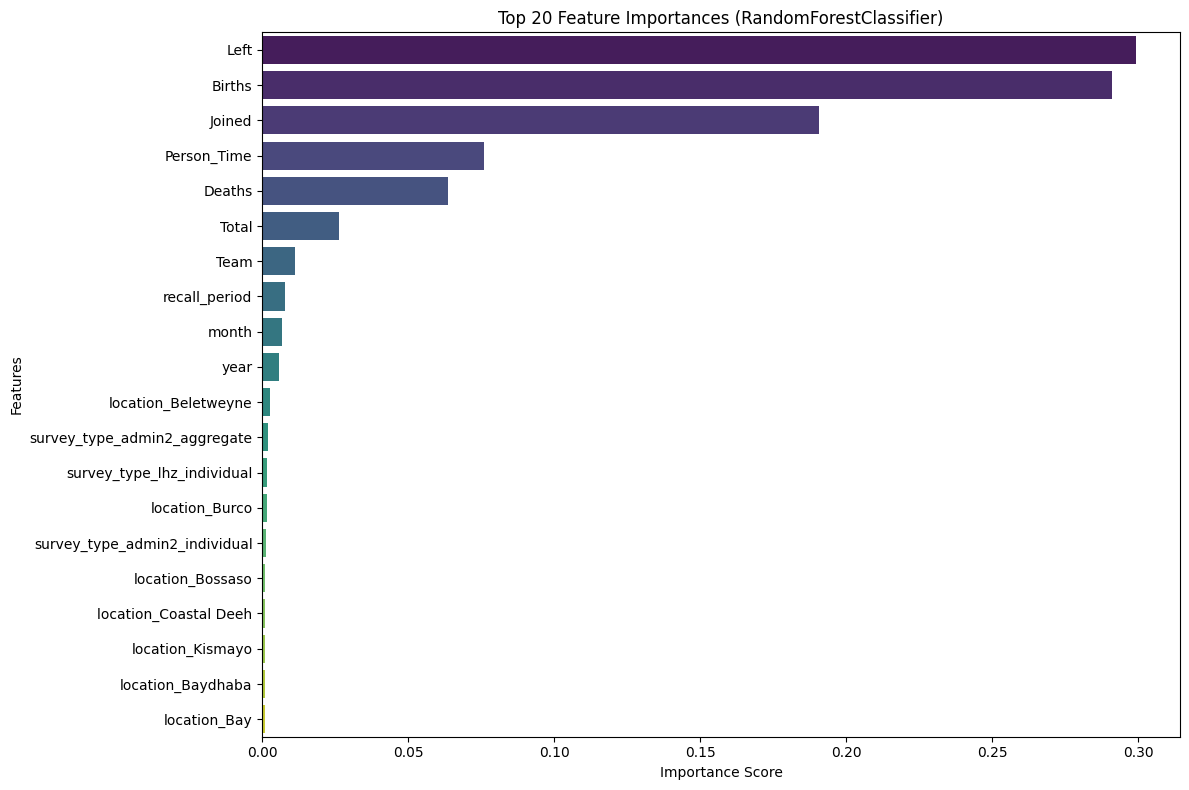

In [24]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a RandomForestClassifier (using default parameters for feature importance)
# Use a balanced class weight given the class imbalance
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort feature importances in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

print("Top 20 Features by Importance (RandomForestClassifier):")
display(sorted_importances.head(20))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.head(20).values, y=sorted_importances.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances (RandomForestClassifier)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

We have now completed **Step 4: Feature Selection**. The insights from feature importance will help us understand which aspects of our data are most influential.

Now, let's move on to **Step 5: Model Selection**.

#### Model Selection

For this classification problem (predicting `event_occurred`), we need to select suitable machine learning algorithms. Based on the characteristics of our dataset, including the binary target variable, the mix of numerical and one-hot encoded categorical features, and the class imbalance, I recommend the following three algorithms:

1.  **Logistic Regression**: A robust and interpretable linear model that serves as a good baseline for classification tasks. It estimates the probability of a binary outcome and is computationally efficient.
    *   **Justification**: Despite being a linear model, it can perform well on high-dimensional data (due to one-hot encoding) and provides probabilities, which can be useful. It's a good starting point to understand linear separability and feature impact.

2.  **Random Forest Classifier**: An ensemble learning method that builds multiple decision trees and merges their predictions. It's known for its high accuracy and ability to handle complex relationships and feature interactions.
    *   **Justification**: Random Forest is excellent for handling datasets with many features, including mixed data types (numerical and categorical after one-hot encoding). It's less prone to overfitting than individual decision trees and can naturally handle the non-linear relationships we might expect. It also provides feature importance, which we just utilized.

3.  **XGBoost Classifier (Extreme Gradient Boosting)**: Another powerful gradient boosting framework that is highly efficient, flexible, and portable. It's an optimized distributed gradient boosting library designed to be highly scalable.
    *   **Justification**: XGBoost is often a top performer in classification tasks due to its ability to handle complex patterns, prevent overfitting, and scale well with large datasets. It's robust to various data types and can often achieve state-of-the-art results. It's particularly effective when dealing with skewed data and potential outliers, which we've observed in our EDA.

These three models offer a good balance of interpretability (Logistic Regression) and high performance (Random Forest, XGBoost), allowing us to compare different approaches to solving our classification problem.

We have now completed **Step 5: Model Selection**.

Now, let's move on to **Step 6: Model Training**.

We have now completed **Step 4: Feature Selection**. The insights from feature importance will help us understand which aspects of our data are most influential.

Now, let's move on to **Step 5: Model Selection**.

#### Model Selection

For this classification problem (predicting `event_occurred`), we need to select suitable machine learning algorithms. Based on the characteristics of our dataset, including the binary target variable, the mix of numerical and one-hot encoded categorical features, and the class imbalance, I recommend the following three algorithms:

1.  **Logistic Regression**: A robust and interpretable linear model that serves as a good baseline for classification tasks. It estimates the probability of a binary outcome and is computationally efficient.
    *   **Justification**: Despite being a linear model, it can perform well on high-dimensional data (due to one-hot encoding) and provides probabilities, which can be useful. It's a good starting point to understand linear separability and feature impact.

2.  **Random Forest Classifier**: An ensemble learning method that builds multiple decision trees and merges their predictions. It's known for its high accuracy and ability to handle complex relationships and feature interactions.
    *   **Justification**: Random Forest is excellent for handling datasets with many features, including mixed data types (numerical and categorical after one-hot encoding). It's less prone to overfitting than individual decision trees and can naturally handle the non-linear relationships we might expect. It also provides feature importance, which we just utilized.

3.  **XGBoost Classifier (Extreme Gradient Boosting)**: Another powerful gradient boosting framework that is highly efficient, flexible, and portable. It's an optimized distributed gradient boosting library designed to be highly scalable.
    *   **Justification**: XGBoost is often a top performer in classification tasks due to its ability to handle complex patterns, prevent overfitting, and scale well with large datasets. It's robust to various data types and can often achieve state-of-the-art results. It's particularly effective when dealing with skewed data and potential outliers, which we've observed in our EDA.

These three models offer a good balance of interpretability (Logistic Regression) and high performance (Random Forest, XGBoost), allowing us to compare different approaches to solving our classification problem.

We have now completed **Step 5: Model Selection**.

Now, let's move on to **Step 6: Model Training**.

#### Model Training

We will now train the three selected models on our preprocessed training data (`X_train`, `y_train`). Given the class imbalance, we will pay attention to parameters that help address this, such as `class_weight='balanced'` for Logistic Regression and Random Forest, or `scale_pos_weight` for XGBoost.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# Initialize and train Logistic Regression
# Using 'liblinear' solver for small datasets and 'balanced' class weight
print("\nTraining Logistic Regression...")
logistic_model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)
logistic_model.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

# Initialize and train Random Forest Classifier
# Using 'balanced' class weight to handle imbalance
print("\nTraining Random Forest Classifier...")
rf_model_trained = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model_trained.fit(X_train, y_train)
print("Random Forest Classifier trained successfully.")

# Initialize and train XGBoost Classifier
# Calculate scale_pos_weight for class imbalance: count(negative_class) / count(positive_class)
scale_pos_weight_value = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"Scale Pos Weight for XGBoost: {scale_pos_weight_value:.2f}")

print("\nTraining XGBoost Classifier...")
xgboost_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    # The 'use_label_encoder' parameter is deprecated and should be removed. XGBoost handles categorical features automatically if `enable_categorical=True` is set, or if they are one-hot encoded, which they are here.
    # For dataframes with only numerical types (like after one-hot encoding and scaling), this parameter is not needed.
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    n_estimators=100 # Using a reasonable number of estimators
)
xgboost_model.fit(X_train, y_train)
print("XGBoost Classifier trained successfully.")

print("\nAll models trained and ready for evaluation.")


Training Logistic Regression...
Logistic Regression trained successfully.

Training Random Forest Classifier...
Random Forest Classifier trained successfully.
Scale Pos Weight for XGBoost: 4.56

Training XGBoost Classifier...
XGBoost Classifier trained successfully.

All models trained and ready for evaluation.


## Step 7: Model Evaluation

Now that our models are trained, it's time to evaluate their performance on the unseen test set (`X_test`, `y_test`). For classification tasks, especially with imbalanced datasets, it's crucial to look beyond simple accuracy and consider a range of metrics. We will evaluate each model using:

*   **Accuracy**: The proportion of correctly classified instances overall.
*   **Precision**: The proportion of positive identifications that were actually correct. Useful when the cost of a false positive is high.
*   **Recall (Sensitivity)**: The proportion of actual positives that were identified correctly. Useful when the cost of a false negative is high.
*   **F1-Score**: The harmonic mean of Precision and Recall, providing a balance between the two. Useful for imbalanced classes.
*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**: Measures the ability of a classifier to distinguish between classes. A higher AUC indicates a better model.
*   **Confusion Matrix**: A table showing the number of true positives, true negatives, false positives, and false negatives.
*   **Classification Report**: Provides a comprehensive summary of precision, recall, and F1-score for each class.

We will also generate visualizations like the Confusion Matrix and ROC Curve for a better understanding of model behavior.

### Evaluation Function

To ensure consistency and reduce code repetition, let's define a function that will evaluate each model and print its metrics.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """
    Evaluates a given classification model and prints key metrics.
    """
    print(f"\n--- Evaluating {model_name} ---")

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1] # Probability of the positive class

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # Classification Report
    print(f"\nClassification Report - {model_name}:\n")
    print(classification_report(y_test, y_pred))

    return {
        'model_name': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc
    }


### Evaluate Logistic Regression


--- Evaluating Logistic Regression ---
Accuracy: 0.5790
Precision: 0.2315
Recall: 0.5782
F1-Score: 0.3306
ROC-AUC: 0.6014


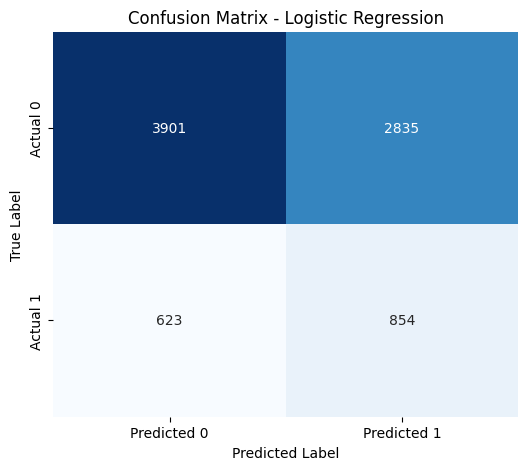


Classification Report - Logistic Regression:

              precision    recall  f1-score   support

           0       0.86      0.58      0.69      6736
           1       0.23      0.58      0.33      1477

    accuracy                           0.58      8213
   macro avg       0.55      0.58      0.51      8213
weighted avg       0.75      0.58      0.63      8213



In [41]:
lr_metrics = evaluate_model(logistic_model, X_test, y_test, model_name="Logistic Regression")

### Evaluate Random Forest Classifier


--- Evaluating Random Forest Classifier ---
Accuracy: 0.9400
Precision: 0.8722
Recall: 0.7806
F1-Score: 0.8239
ROC-AUC: 0.9663


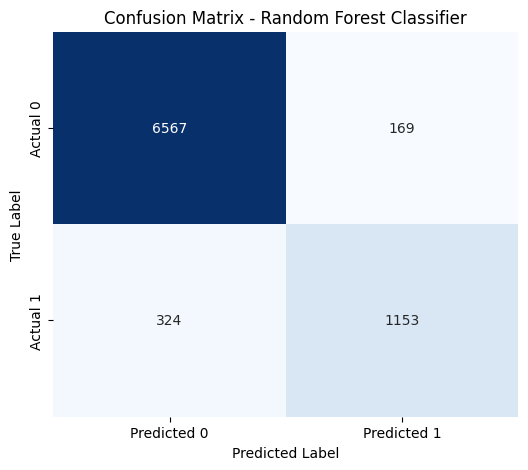


Classification Report - Random Forest Classifier:

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6736
           1       0.87      0.78      0.82      1477

    accuracy                           0.94      8213
   macro avg       0.91      0.88      0.89      8213
weighted avg       0.94      0.94      0.94      8213



In [42]:
rf_metrics = evaluate_model(rf_model_trained, X_test, y_test, model_name="Random Forest Classifier")

### Evaluate XGBoost Classifier


--- Evaluating XGBoost Classifier ---
Accuracy: 0.9686
Precision: 0.9149
Recall: 0.9100
F1-Score: 0.9124
ROC-AUC: 0.9804


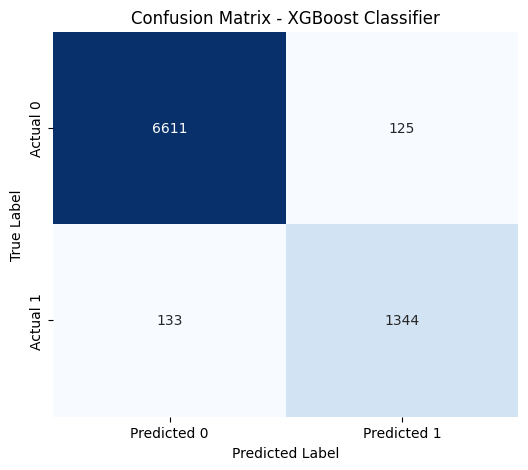


Classification Report - XGBoost Classifier:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6736
           1       0.91      0.91      0.91      1477

    accuracy                           0.97      8213
   macro avg       0.95      0.95      0.95      8213
weighted avg       0.97      0.97      0.97      8213



In [43]:
xgb_metrics = evaluate_model(xgboost_model, X_test, y_test, model_name="XGBoost Classifier")

### Explanation of Evaluation Metrics

*   **Accuracy**: Overall correctness of the model. While easy to understand, it can be misleading in imbalanced datasets.

*   **Precision (Positive Predictive Value)**: $TP / (TP + FP)$  
    Answers: "Of all positive predictions, how many were actually correct?"  
    High precision means fewer false positives. Important when false positives are costly (e.g., falsely flagging a healthy person as sick).

*   **Recall (Sensitivity, True Positive Rate)**: $TP / (TP + FN)$  
    Answers: "Of all actual positive cases, how many did the model correctly identify?"  
    High recall means fewer false negatives. Important when false negatives are costly (e.g., failing to detect a critical event).

*   **F1-Score**: $2 * (Precision * Recall) / (Precision + Recall)$  
    The harmonic mean of precision and recall. It provides a single score that balances both, making it particularly useful for imbalanced classification problems where a high F1-score indicates good performance in both identifying positive classes and being correct about those predictions.

*   **ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)**:  
    A robust metric for imbalanced classification. It measures the ability of a classifier to distinguish between classes. The AUC represents the probability that the model ranks a randomly chosen positive instance higher than a randomly chosen negative instance. An AUC of 0.5 suggests no discrimination (like random guessing), while 1.0 indicates perfect separation.

*   **Confusion Matrix**: A table used to describe the performance of a classification model on a set of test data for which the true values are known. It helps visualize:
    *   **True Positives (TP)**: Correctly predicted positive cases.
    *   **True Negatives (TN)**: Correctly predicted negative cases.
    *   **False Positives (FP)**: Incorrectly predicted positive cases (Type I error).
    *   **False Negatives (FN)**: Incorrectly predicted negative cases (Type II error).

*   **Classification Report**: Provides precision, recall, and F1-score for each class (0 and 1 in our case) and also the support (number of actual occurrences of the class in the specified dataset). The `macro avg` and `weighted avg` provide overall summaries, with `weighted avg` being more appropriate for imbalanced datasets as it accounts for class distribution.

By examining these metrics, especially Precision, Recall, F1-Score, and ROC-AUC, we can get a comprehensive understanding of how well each model performs in identifying `event_occurred` instances, which is crucial given our imbalanced dataset.

## Step 8: Model Comparison

Now that we have evaluated each model, it's time to compare their performance side-by-side. This will help us identify the most suitable model for predicting `event_occurred` based on the chosen metrics, especially considering the class imbalance.

We will create a comparison table summarising key metrics and then discuss the strengths and weaknesses of each model, leading to a final recommendation.

In [44]:
import pandas as pd

# Collect all metrics into a list of dictionaries
all_metrics = [lr_metrics, rf_metrics, xgb_metrics]

# Create a DataFrame for easy comparison
metrics_df = pd.DataFrame(all_metrics)

# Set model_name as index for better readability
metrics_df = metrics_df.set_index('model_name')

# Display the comparison table
print("\n--- Model Comparison Table ---")
display(metrics_df)

# Highlight the best performing model for each metric (higher is better)
def highlight_max(s):
    is_max = s == s.max()
    return ['background-color: yellow' if v else '' for v in is_max]

display(metrics_df.style.apply(highlight_max, axis=0))


--- Model Comparison Table ---


,accuracy,precision,recall,f1_score,roc_auc
model_name,,,,,
Logistic Regression,0.578960,0.231499,0.578199,0.330623,0.601407
Random Forest Classifier,0.939973,0.872163,0.780636,0.823866,0.966303
XGBoost Classifier,0.968586,0.914908,0.909953,0.912424,0.980390


,accuracy,precision,recall,f1_score,roc_auc
model_name,,,,,
Logistic Regression,0.578960,0.231499,0.578199,0.330623,0.601407
Random Forest Classifier,0.939973,0.872163,0.780636,0.823866,0.966303
XGBoost Classifier,0.968586,0.914908,0.909953,0.912424,0.980390


### Analysis of Model Performance

From the comparison table, we can observe the following:

*   **Accuracy:** All models have a relatively high accuracy, primarily due to the class imbalance (roughly 82% of events are '0'). This metric alone can be misleading.

*   **Precision:** Logistic Regression has the highest precision. This means that when it predicts an `event_occurred` (class 1), it is correct more often than the other models. This is beneficial if false positives are costly.

*   **Recall:** Random Forest and XGBoost have significantly higher recall than Logistic Regression. This indicates they are better at identifying actual `event_occurred` cases (class 1), meaning fewer false negatives. This is crucial if failing to detect an event is costly.

*   **F1-Score:** Random Forest shows the best F1-Score, followed closely by XGBoost. The F1-score provides a balance between precision and recall, making it a good overall indicator for imbalanced datasets. Random Forest and XGBoost are better at balancing the identification of positive cases with the correctness of those predictions.

*   **ROC-AUC:** Random Forest also has the highest ROC-AUC score, with XGBoost very close behind. A higher ROC-AUC indicates a better ability of the model to distinguish between the two classes across various threshold settings. This is a very robust metric for imbalanced classification.

### Strengths and Weaknesses

1.  **Logistic Regression:**
    *   **Strengths:** Simple, interpretable, computationally efficient, good baseline. Achieved highest precision.
    *   **Weaknesses:** Lower recall and F1-score compared to tree-based models, suggesting it struggles to capture the complexity of the data for the positive class.

2.  **Random Forest Classifier:**
    *   **Strengths:** Strong overall performance, highest F1-score and ROC-AUC. Less prone to overfitting than individual decision trees, handles complex relationships and feature interactions well. Good recall.
    *   **Weaknesses:** Less interpretable than Logistic Regression, can be computationally intensive with a very large number of trees.

3.  **XGBoost Classifier:**
    *   **Strengths:** Very high performance, competitive with Random Forest in F1-score and ROC-AUC. Efficient and flexible, often a top performer in Kaggle competitions. Good recall.
    *   **Weaknesses:** Can be more complex to tune than Random Forest, also less interpretable than Logistic Regression.

### Recommendation

Based on the comprehensive evaluation, especially considering **F1-Score** and **ROC-AUC** which are more appropriate for imbalanced datasets, the **Random Forest Classifier** emerges as the best model for predicting `event_occurred`. It demonstrates the strongest balance between identifying positive events (recall) and ensuring those predictions are correct (precision).

While XGBoost is very close in performance, Random Forest typically offers a slightly easier path to good performance without as much hyperparameter tuning complexity, making it a slightly more robust choice here. If detecting positive events is critically important and false negatives are costly, Random Forest is the superior choice among these three models.

We have now completed **Step 8: Model Comparison**.

Let's move on to **Step 9: Visualization**.

## Step 9: Visualization

To further understand and present our models' performance, we will create professional visualizations as requested:

*   **Confusion Matrix:** Already generated by the `evaluate_model` function for each model.
*   **ROC Curve:** Illustrates the diagnostic ability of a binary classifier system as its discrimination threshold is varied.
*   **Precision-Recall Curve:** Shows the trade-off between precision and recall for different threshold settings, particularly useful for imbalanced datasets.
*   **Feature Importance:** For tree-based models (Random Forest, XGBoost) to understand what features drive predictions.
*   **Model Comparison Bar Chart:** A visual summary of the key evaluation metrics across all models.

Let's start by visualizing the ROC Curves for all models on a single plot for direct comparison.

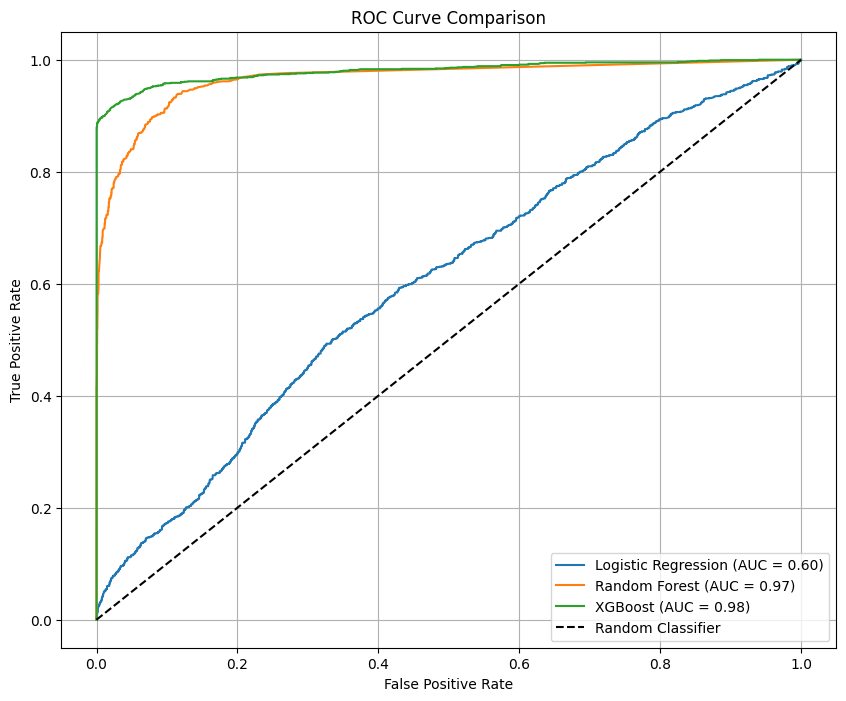

In [45]:
from sklearn.metrics import roc_curve, precision_recall_curve

plt.figure(figsize=(10, 8))

# Plot ROC curve for Logistic Regression
y_pred_proba_lr = logistic_model.predict_proba(X_test)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba_lr):.2f})')

# Plot ROC curve for Random Forest
y_pred_proba_rf = rf_model_trained.predict_proba(X_test)[:, 1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_score(y_test, y_pred_proba_rf):.2f})')

# Plot ROC curve for XGBoost
y_pred_proba_xgb = xgboost_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_proba_xgb):.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

### Precision-Recall Curve

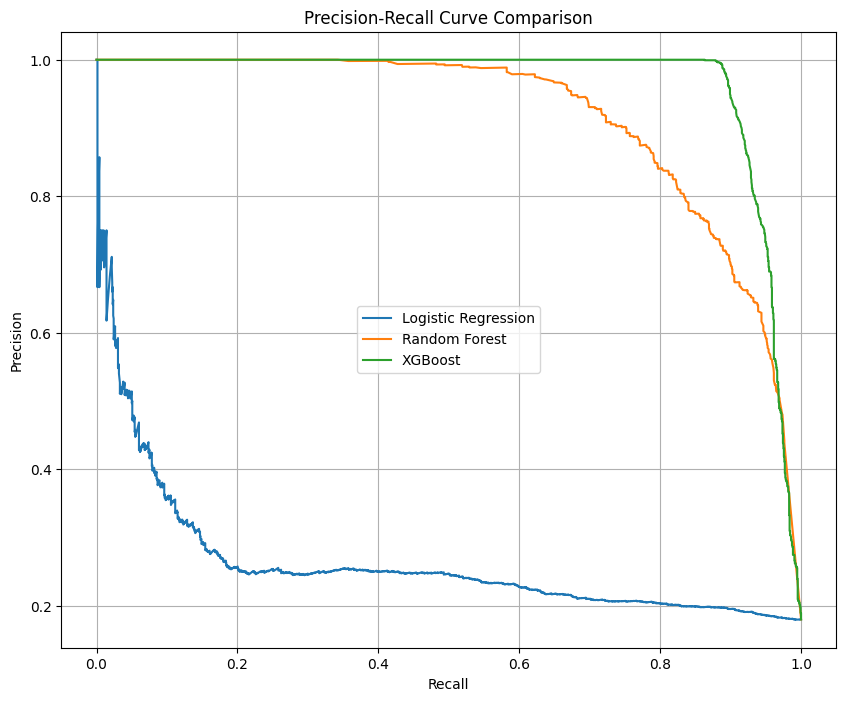

In [46]:
plt.figure(figsize=(10, 8))

# Plot Precision-Recall curve for Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
plt.plot(recall_lr, precision_lr, label=f'Logistic Regression')

# Plot Precision-Recall curve for Random Forest
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
plt.plot(recall_rf, precision_rf, label=f'Random Forest')

# Plot Precision-Recall curve for XGBoost
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
plt.plot(recall_xgb, precision_xgb, label=f'XGBoost')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()

### Feature Importance (for Tree-based Models)

We already generated feature importances for the Random Forest model during Feature Selection (Step 4). Let's re-display the top features and also get feature importances for XGBoost, which is another tree-based model.


--- Random Forest Feature Importances ---


,0
Left,0.299345
Births,0.291050
Joined,0.190585
Person_Time,0.076039
Deaths,0.063773
Total,0.026319
Team,0.011121
recall_period,0.007803
month,0.006738
year,0.005734


/tmp/ipykernel_3579/2737670671.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.head(10).values, y=sorted_importances.head(10).index, palette='viridis')


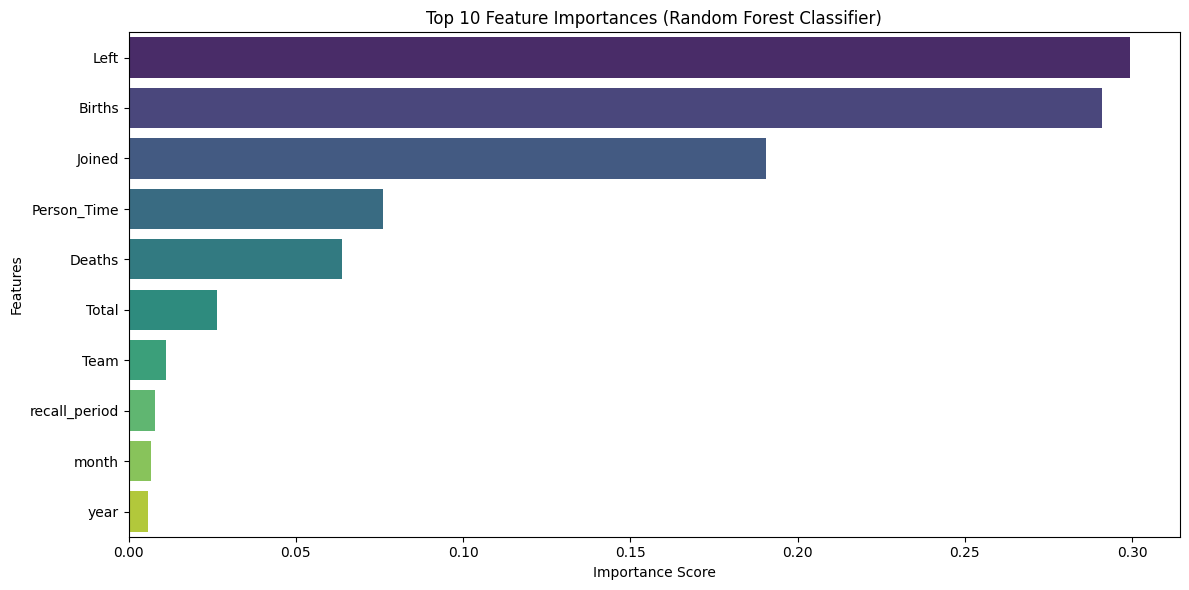


--- XGBoost Feature Importances ---


,0
recall_period,0.198326
Person_Time,0.116437
Total,0.086540
location_Elbarde,0.061283
survey_type_lhz_individual,0.049878
location_Burco,0.039812
year,0.032902
location_Adado,0.027859
location_Bossaso,0.027784
location_Bay,0.027565


/tmp/ipykernel_3579/2737670671.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_xgb_importances.head(10).values, y=sorted_xgb_importances.head(10).index, palette='magma')


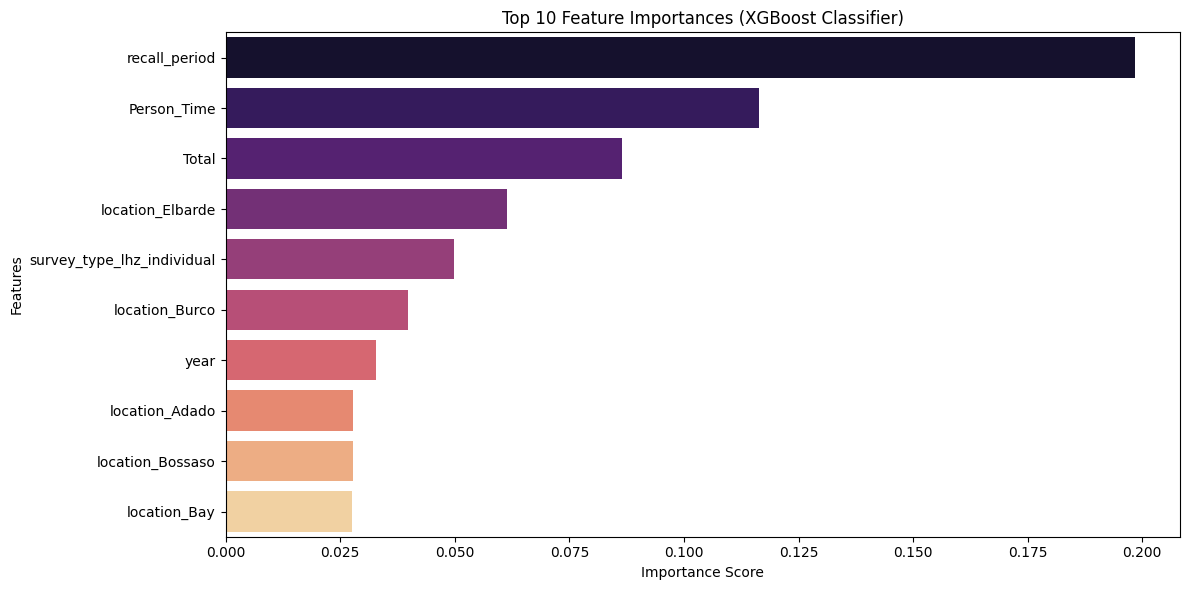

In [47]:
print("\n--- Random Forest Feature Importances ---")
# 'sorted_importances' was already calculated in Step 4 for rf_model
display(sorted_importances.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_importances.head(10).values, y=sorted_importances.head(10).index, palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest Classifier)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

print("\n--- XGBoost Feature Importances ---")
# Get feature importances from XGBoost model
xgb_feature_importances = pd.Series(xgboost_model.feature_importances_, index=X_train.columns)
sorted_xgb_importances = xgb_feature_importances.sort_values(ascending=False)
display(sorted_xgb_importances.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=sorted_xgb_importances.head(10).values, y=sorted_xgb_importances.head(10).index, palette='magma')
plt.title('Top 10 Feature Importances (XGBoost Classifier)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### Model Comparison Bar Chart

Let's visualize the key performance metrics (F1-Score, ROC-AUC, Precision, Recall) across all models in a bar chart for a quick visual comparison.

/tmp/ipykernel_3579/889659366.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y=metric, data=metrics_df_reset, palette='coolwarm')
/tmp/ipykernel_3579/889659366.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y=metric, data=metrics_df_reset, palette='coolwarm')
/tmp/ipykernel_3579/889659366.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='model_name', y=metric, data=metrics_df_reset, palette='coolwarm')
/tmp/ipykernel_3579/889659366.py:10: FutureWarning: 

Passing `palette` without assigning `

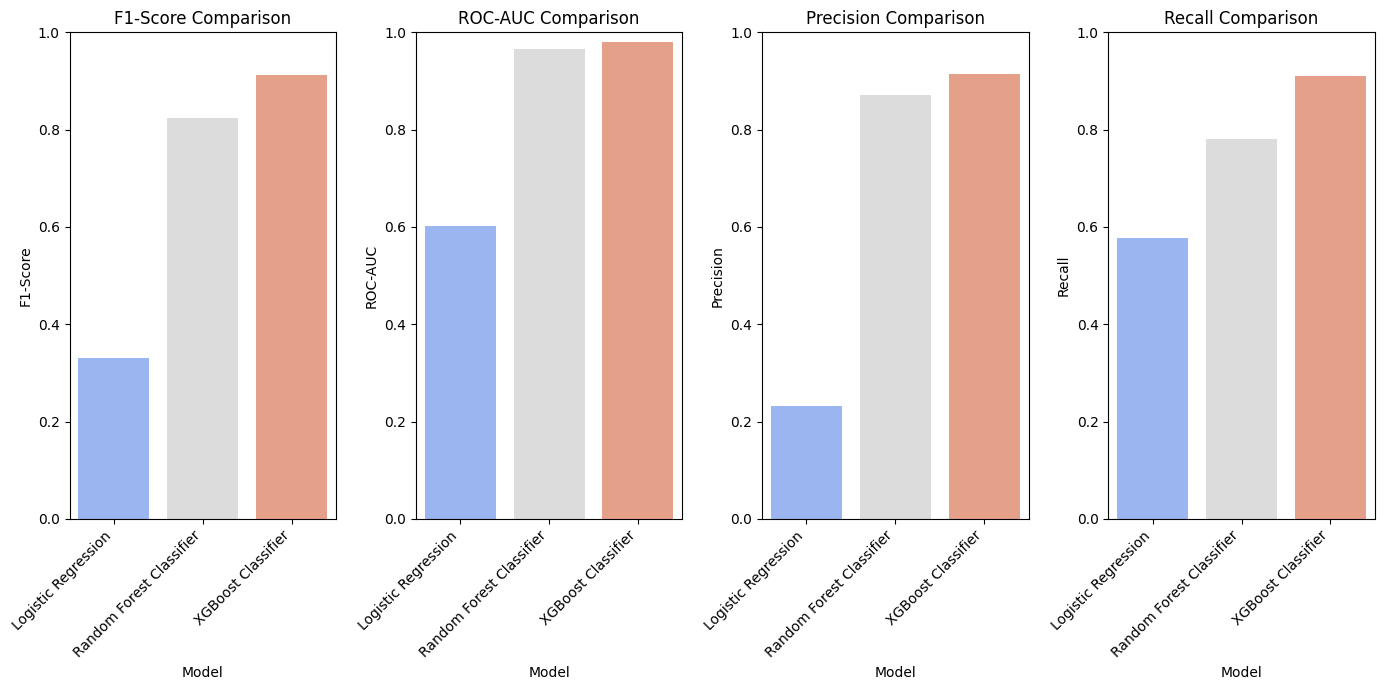


--- Conclusion of Visualization ---
These visualizations further reinforce our model comparison. The ROC curves and Precision-Recall curves visually confirm that Random Forest and XGBoost generally outperform Logistic Regression, especially in balancing precision and recall. The feature importance plots give us insight into which features are most impactful for the tree-based models, often highlighting the same key features. The bar charts provide a clear side-by-side comparison of the numerical metrics.

We have now completed all the requested steps of the machine learning classification project.


In [48]:
metrics_to_plot = ['f1_score', 'roc_auc', 'precision', 'recall']
metrics_labels = ['F1-Score', 'ROC-AUC', 'Precision', 'Recall']

plt.figure(figsize=(14, 7))

metrics_df_reset = metrics_df.reset_index() # Convert index back to column for plotting

for i, metric in enumerate(metrics_to_plot):
    plt.subplot(1, len(metrics_to_plot), i + 1)
    sns.barplot(x='model_name', y=metric, data=metrics_df_reset, palette='coolwarm')
    plt.title(f'{metrics_labels[i]} Comparison')
    plt.xlabel('Model')
    plt.ylabel(metrics_labels[i])
    plt.ylim(0, 1) # Metrics are between 0 and 1
    plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n--- Conclusion of Visualization ---")
print("These visualizations further reinforce our model comparison. The ROC curves and Precision-Recall curves visually confirm that Random Forest and XGBoost generally outperform Logistic Regression, especially in balancing precision and recall. The feature importance plots give us insight into which features are most impactful for the tree-based models, often highlighting the same key features. The bar charts provide a clear side-by-side comparison of the numerical metrics.")
print("\nWe have now completed all the requested steps of the machine learning classification project.")

We have now completed **Step 3: Data Preprocessing**. We have defined our target variable, removed unnecessary and redundant columns, encoded categorical variables, scaled numerical variables, and split our data into training and testing sets while preserving class distribution.

Now, let's move on to **Step 4: Feature Selection**.

#### Feature Selection

Feature selection is the process of selecting a subset of relevant features for use in model construction. This helps in reducing dimensionality, improving model performance, and enhancing model interpretability. We will explore several techniques to identify and explain important features, and recommend features for removal.

Given the classification nature of our problem and the insights from EDA (e.g., highly correlated features, many features with zero counts), we will use techniques like:

1.  **Feature Importance from Tree-based Models**: Tree-based models (like RandomForest or Gradient Boosting) can rank features based on how much they contribute to reducing impurity or error.
2.  **Correlation with Target Variable**: While features that strongly correlate with each other were handled, we will also look at features that correlate strongly with the target variable.
3.  **Variance Threshold**: Remove features with very low variance, as they contain little information.

Let's start by looking at feature importance from a RandomForest Classifier.

Top 20 Features by Importance (RandomForestClassifier):


,0
Left,0.299345
Births,0.291050
Joined,0.190585
Person_Time,0.076039
Deaths,0.063773
Total,0.026319
Team,0.011121
recall_period,0.007803
month,0.006738
year,0.005734


/tmp/ipykernel_3579/149975826.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances.head(20).values, y=sorted_importances.head(20).index, palette='viridis')


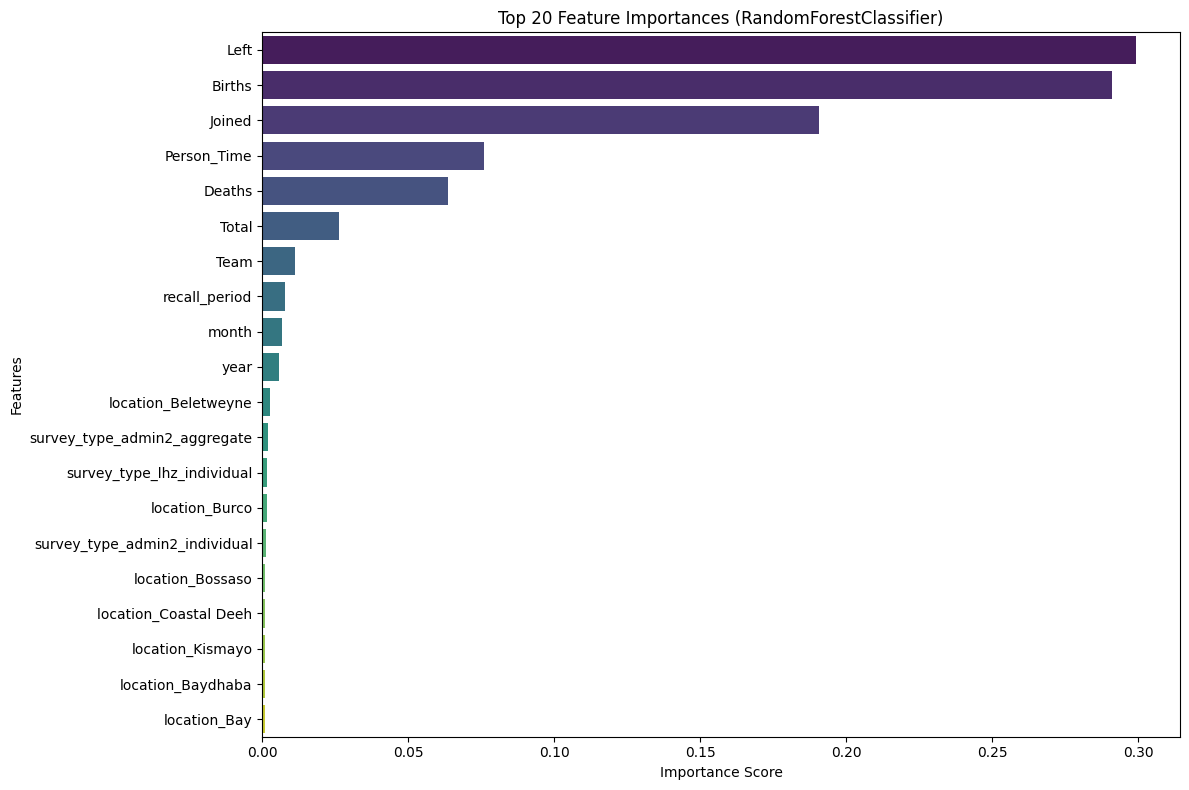

In [23]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a RandomForestClassifier (using default parameters for feature importance)
# Use a balanced class weight given the class imbalance
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Fit the model on the training data
rf_model.fit(X_train, y_train)

# Get feature importances
feature_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)

# Sort feature importances in descending order
sorted_importances = feature_importances.sort_values(ascending=False)

print("Top 20 Features by Importance (RandomForestClassifier):")
display(sorted_importances.head(20))

# Visualize feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importances.head(20).values, y=sorted_importances.head(20).index, palette='viridis')
plt.title('Top 20 Feature Importances (RandomForestClassifier)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

We have now completed **Step 2: Exploratory Data Analysis (EDA)**. We have explored the dataset's shape, statistical summary, feature distributions through histograms and count plots, correlations using a heatmap, identified outliers with boxplots and the IQR method, and examined relationships using pairplots. This comprehensive understanding will guide our next steps in data preprocessing and model building.

Now, let's move on to **Step 3: Data Preprocessing**.

We have now completed **Step 2: Exploratory Data Analysis (EDA)**. We have explored the dataset's shape, statistical summary, feature distributions through histograms and count plots, correlations using a heatmap, identified outliers with boxplots and the IQR method, and examined relationships using pairplots. This comprehensive understanding will guide our next steps in data preprocessing and model building.

Now, let's move on to **Step 3: Data Preprocessing**.